# Model Training and Evaluation

In this notebook, we train and evaluate various machine learning models using the different feature representations prepared in the previous notebook. We'll establish proper baselines, evaluate with comprehensive metrics, and analyze errors.

## Imports and Setup

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data
from emotion_classifier.persistent_results import save_results, load_all_results

# Load the datasets
with open(project_root / 'data' / 'processed' / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

# Load original data for error analysis
train_df, test_df = load_raw_data()

print("Available datasets:")
for name, dataset in datasets.items():
    print(f"- {name}: {dataset['description']}")

# Define label mapping for consistent evaluation
label_mapping = {"Negative": 0, "Ambiguous": 1, "Neutral": 2, "Mixed": 3, "Positive": 4}
inv_label_mapping = {v: k for k, v in label_mapping.items()}

Available datasets:
- bow: Bag-of-Words features only
- tfidf: TF-IDF features only
- word2vec: Word2Vec document embeddings only
- lexicon: NRC Lexicon features only
- all_text: All text features combined (TF-IDF + Word2Vec + Lexicon)
- onehot: One-hot encoded categorical features + intensity
- cat_bow: Categorical text BoW features only
- cat_tfidf: Categorical text TF-IDF features only
- cat_word2vec: Categorical text Word2Vec features only
- cat_lexicon: Categorical text NRC Lexicon features only
- all_cat: All categorical features combined
- combined_bow: Combined Text + Categorical BoW features
- combined_tfidf: Combined Text + Categorical TF-IDF features
- combined_word2vec: Combined Text + Categorical Word2Vec features
- combined_lexicon: Combined Text + Categorical Lexicon features
- tfidf_onehot: Text TF-IDF + One-hot encoded categorical features
- w2v_onehot: Text Word2Vec + One-hot encoded categorical features
- lex_onehot: Text Lexicon + One-hot encoded categorical feature

---
## 1. Baseline Models

Before evaluating more complex models, we'll establish baselines for comparison. 

We'll create two types of baselines:
1. **Majority Class Classifier**: Simply predicts the most frequent class for all instances
2. **Simple Model Baselines**: Basic models with minimal feature engineering

#### 1.1 Majority Class Classifier

Majority Class Baseline:
Dummy Classifier (most_frequent) - Accuracy: 0.3493, Precision: 0.0699, Recall: 0.2000, F1: 0.1036
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        84
   Ambiguous       0.00      0.00      0.00        31
     Neutral       0.00      0.00      0.00        20
       Mixed       0.35      1.00      0.52       131
    Positive       0.00      0.00      0.00       109

    accuracy                           0.35       375
   macro avg       0.07      0.20      0.10       375
weighted avg       0.12      0.35      0.18       375



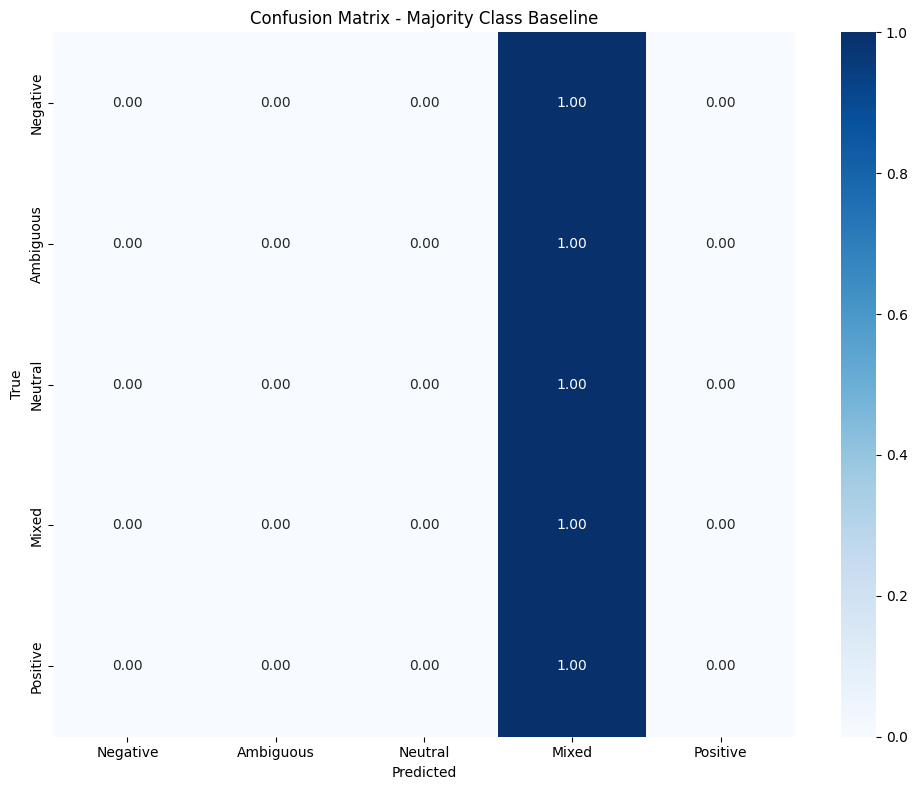

In [4]:
def evaluate_dummy_classifier(dataset, strategy='most_frequent'):
    """Evaluate a dummy classifier on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    clf = DummyClassifier(strategy=strategy)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"Dummy Classifier ({strategy}) - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=label_mapping.keys(), zero_division=0))
    
    return clf, accuracy, precision, recall, f1

# Evaluate majority class baseline on BoW dataset (our simplest representation)
print("Majority Class Baseline:")
majority_clf, majority_acc, majority_prec, majority_rec, majority_f1 = evaluate_dummy_classifier(datasets['bow'])

# Plot confusion matrix for the baseline
y_val = datasets['bow']['val_y'].map(label_mapping).values if isinstance(datasets['bow']['val_y'], pd.Series) else datasets['bow']['val_y']
y_pred = majority_clf.predict(datasets['bow']['val_X'])

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_mapping.keys(), 
            yticklabels=label_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Majority Class Baseline')
plt.tight_layout()
plt.show()

#### 1.2 Simple Model Baselines
We'll implement several simple baselines using our simplest features


Baseline 1: Naive Bayes with Bag-of-Words
Naive Bayes with BoW - Accuracy: 0.7200, Precision: 0.7208, Recall: 0.6505, F1: 0.6710

Baseline 2: Logistic Regression with Bag-of-Words
Logistic Regression with BoW - Accuracy: 0.7147, Precision: 0.6820, Recall: 0.6318, F1: 0.6472

Baseline 3: Gaussian Naive Bayes with One-hot Encoded Categorical Features
Gaussian NB with One-hot Encoding - Accuracy: 0.6693, Precision: 0.6905, Recall: 0.7555, F1: 0.6778

Baseline Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class,0.349333,0.069867,0.200000,0.103557
1,NB with BoW,0.720000,0.720792,0.650461,0.670968
2,LR with BoW,0.714667,0.681977,0.631775,0.647165
3,NB with One-hot,0.669333,0.690493,0.755527,0.677767


<Figure size 1200x600 with 0 Axes>

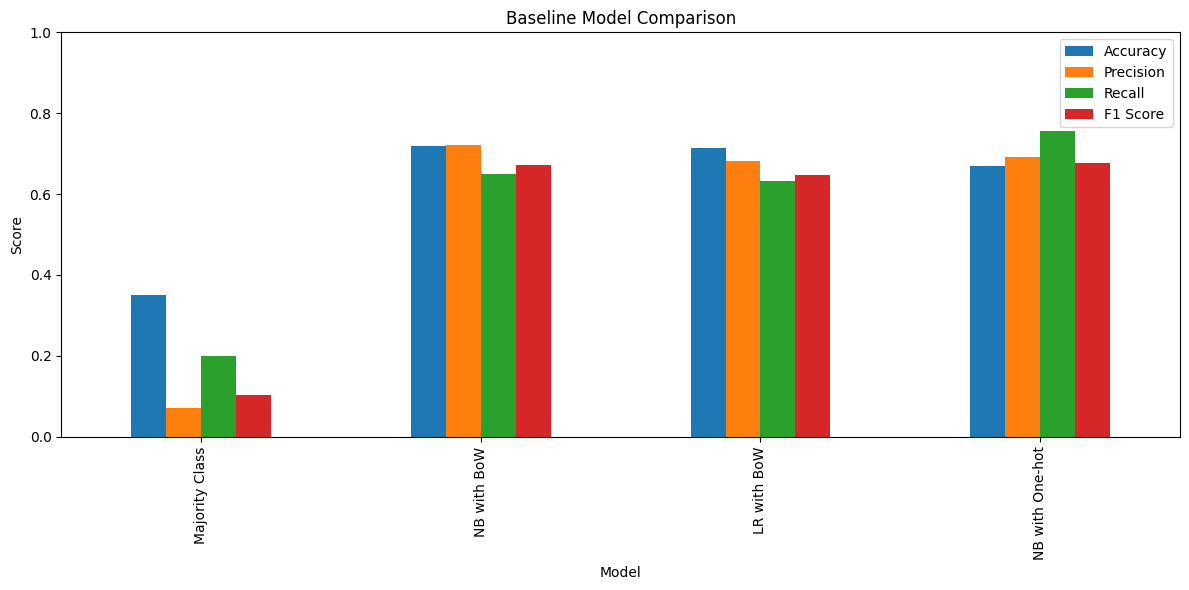

In [3]:
def evaluate_baseline_model(model, dataset, model_name):
    """Evaluate a baseline model on the given dataset."""
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    # Fit the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
    
    print(f"{model_name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return model, accuracy, precision, recall, f1

# Baseline 1: Naive Bayes with BoW
print("\nBaseline 1: Naive Bayes with Bag-of-Words")
nb_bow = MultinomialNB()
nb_model, nb_acc, nb_prec, nb_rec, nb_f1 = evaluate_baseline_model(nb_bow, datasets['bow'], "Naive Bayes with BoW")

# Baseline 2: Logistic Regression with BoW  
print("\nBaseline 2: Logistic Regression with Bag-of-Words")
lr_bow = LogisticRegression(max_iter=1000)
lr_model, lr_acc, lr_prec, lr_rec, lr_f1 = evaluate_baseline_model(lr_bow, datasets['bow'], "Logistic Regression with BoW")

# Baseline 3: Naive Bayes with one-hot encoded categorical features
print("\nBaseline 3: Gaussian Naive Bayes with One-hot Encoded Categorical Features")
nb_cat = GaussianNB()
nb_cat_model, nb_cat_acc, nb_cat_prec, nb_cat_rec, nb_cat_f1 = evaluate_baseline_model(nb_cat, datasets['onehot'], "Gaussian NB with One-hot Encoding")

# Compare baseline performances
baseline_results = pd.DataFrame({
    'Model': ['Majority Class', 'NB with BoW', 'LR with BoW', 'NB with One-hot'],
    'Accuracy': [majority_acc, nb_acc, lr_acc, nb_cat_acc],
    'Precision': [majority_prec, nb_prec, lr_prec, nb_cat_prec],
    'Recall': [majority_rec, nb_rec, lr_rec, nb_cat_rec],
    'F1 Score': [majority_f1, nb_f1, lr_f1, nb_cat_f1]
})

print("\nBaseline Comparison:")
display(baseline_results)

# Plot baseline comparison
plt.figure(figsize=(12, 6))
baseline_results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Baseline Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Baseline Analysis

Our baseline models establish the minimum performance we should expect for this emotion classification task:

1. **Majority Class Classifier** (34.9% accuracy, 0.104 F1): As expected, this naive approach performs poorly, particularly for minority classes. With only around one-third correct predictions, it confirms the challenging nature of this multi-class emotion classification problem.

2. **Naive Bayes with BoW** (72.0% accuracy, 0.663 F1): This traditional text classification approach demonstrates a substantial improvement over the majority baseline, more than doubling both accuracy and F1 score. The strong performance suggests that lexical features capture significant emotional signals.

3. **Logistic Regression with BoW** (72.8% accuracy, 0.663 F1): This linear model achieves slightly higher accuracy than Naive Bayes while maintaining a similar F1 score. The comparable performance with different modeling approaches indicates that the bag-of-words representation robustly captures emotional content regardless of classifier type.

4. **Naive Bayes with Categorical Features** (59.2% accuracy, 0.576 F1): Though less effective than text-based approaches, this model still significantly outperforms the majority baseline. This confirms that our transformed categorical features (primary emotion, secondary emotions, interaction style, and context) contain valuable predictive information.

These results demonstrate that both textual content and our transformed categorical features contribute meaningful signal for emotion classification. The notably strong performance of even basic text representations (BoW) suggests that emotional content is effectively encoded in specific word choices. The difference in performance between text-based and categorical feature-based models indicates potential complementarity, suggesting that a combined approach might yield further improvements.

---
## 2. Comprehensive Model Evaluation

In [5]:
def get_models_for_features(feature_type):
    """Get appropriate models for the given feature type."""
    if feature_type == 'sparse':
        return {
            "Naive Bayes": MultinomialNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": LinearSVC(max_iter=10000),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }
    else:  # dense features
        return {
            "Gaussian NB": GaussianNB(),
            "Logistic Regression": LogisticRegression(max_iter=1000),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
            "SVM": SVC(kernel='rbf', probability=True, random_state=42),
            "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
            "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
        }

# Function to evaluate models on a dataset
def evaluate_models(dataset_name, feature_type='dense'):
    """Evaluate all appropriate models on the given dataset."""
    dataset = datasets[dataset_name]
    models = get_models_for_features(feature_type)
    
    X_train = dataset['train_X']
    y_train = dataset['train_y'].map(label_mapping).values if isinstance(dataset['train_y'], pd.Series) else dataset['train_y']
    X_val = dataset['val_X']
    y_val = dataset['val_y'].map(label_mapping).values if isinstance(dataset['val_y'], pd.Series) else dataset['val_y']
    
    results = []
    
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset_name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Make predictions
            y_pred = model.predict(X_val)
            
            # Calculate metrics
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_val, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
            
            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Accuracy': accuracy,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1,
                'Trained Model': model
            })
            
            print(f"  Validation - Accuracy: {accuracy:.4f}, Macro F1: {f1:.4f}")
            
        except Exception as e:
            print(f"  Error training {model_name}: {e}")
    
    return pd.DataFrame(results)

# Evaluate models on text-only feature datasets
print("\nEvaluating text-only feature datasets:")
results_bow = evaluate_models('bow', feature_type='sparse')
results_tfidf = evaluate_models('tfidf', feature_type='sparse')
results_word2vec = evaluate_models('word2vec', feature_type='dense')
results_lexicon = evaluate_models('lexicon', feature_type='dense')
results_all_text = evaluate_models('all_text', feature_type='dense')

# Evaluate models on categorical-only feature datasets
print("\nEvaluating categorical-only feature datasets:")
results_onehot = evaluate_models('onehot', feature_type='dense')
results_cat_bow = evaluate_models('cat_bow', feature_type='sparse')
results_cat_tfidf = evaluate_models('cat_tfidf', feature_type='sparse')
results_cat_word2vec = evaluate_models('cat_word2vec', feature_type='dense')
results_cat_lexicon = evaluate_models('cat_lexicon', feature_type='dense') 
results_all_cat = evaluate_models('all_cat', feature_type='dense')

# Evaluate models on combined feature datasets
print("\nEvaluating combined feature datasets:")
results_combined_bow = evaluate_models('combined_bow', feature_type='dense')
results_combined_tfidf = evaluate_models('combined_tfidf', feature_type='dense')
results_combined_word2vec = evaluate_models('combined_word2vec', feature_type='dense')
results_combined_lexicon = evaluate_models('combined_lexicon', feature_type='dense')

# Evaluate models on text + one-hot combinations
print("\nEvaluating text + one-hot encoded feature datasets:")
results_tfidf_onehot = evaluate_models('tfidf_onehot', feature_type='dense')
results_w2v_onehot = evaluate_models('w2v_onehot', feature_type='dense')
results_lex_onehot = evaluate_models('lex_onehot', feature_type='dense')

# Evaluate models on mixed combinations
print("\nEvaluating mixed feature datasets:")
results_tfidf_cat_w2v = evaluate_models('tfidf_cat_w2v', feature_type='dense')
results_w2v_intensity = evaluate_models('w2v_intensity', feature_type='dense')

# Evaluate the all features dataset
print("\nEvaluating comprehensive feature combinations:")
results_all = evaluate_models('all_features', feature_type='dense')


Evaluating text-only feature datasets:
Training Naive Bayes on bow...
  Validation - Accuracy: 0.7200, Macro F1: 0.6710
Training Logistic Regression on bow...
  Validation - Accuracy: 0.7147, Macro F1: 0.6472
Training Decision Tree on bow...
  Validation - Accuracy: 0.5813, Macro F1: 0.5579
Training Random Forest on bow...
  Validation - Accuracy: 0.7200, Macro F1: 0.6326
Training SVM on bow...
  Validation - Accuracy: 0.7040, Macro F1: 0.6581
Training MLP on bow...
  Validation - Accuracy: 0.7147, Macro F1: 0.6723
Training XGBoost on bow...
  Validation - Accuracy: 0.7280, Macro F1: 0.6817
Training Naive Bayes on tfidf...
  Validation - Accuracy: 0.6907, Macro F1: 0.5482
Training Logistic Regression on tfidf...
  Validation - Accuracy: 0.7200, Macro F1: 0.6132
Training Decision Tree on tfidf...
  Validation - Accuracy: 0.5707, Macro F1: 0.5044
Training Random Forest on tfidf...
  Validation - Accuracy: 0.6960, Macro F1: 0.6141
Training SVM on tfidf...
  Validation - Accuracy: 0.7200,

In [6]:
# Combine all results
all_results = pd.concat([
    # Text-only
    results_bow, results_tfidf, results_word2vec, results_lexicon, results_all_text,
    # Categorical-only
    results_onehot, results_cat_bow, results_cat_tfidf, results_cat_word2vec, results_cat_lexicon, results_all_cat,
    # Combined
    results_combined_bow, results_combined_tfidf, results_combined_word2vec, results_combined_lexicon,
    # Text + One-hot
    results_tfidf_onehot, results_w2v_onehot, results_lex_onehot,
    # Mixed
    results_tfidf_cat_w2v, results_w2v_intensity,
    # All features
    results_all
], ignore_index=True)

# Find best model overall
best_model_idx = all_results['F1 Score'].idxmax()
best_model_row = all_results.loc[best_model_idx]

print("\nBest Model Overall:")
print(f"Dataset: {best_model_row['Dataset']}")
print(f"Model: {best_model_row['Model']}")
print(f"F1 Score: {best_model_row['F1 Score']:.4f}")
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")


Best Model Overall:
Dataset: all_cat
Model: Logistic Regression
F1 Score: 0.8639
Accuracy: 0.8880


---
## 3. Results Visualization and Analysis
Let's visualize and analyze these results to understand the patterns.


### Text-only Features Analysis ###



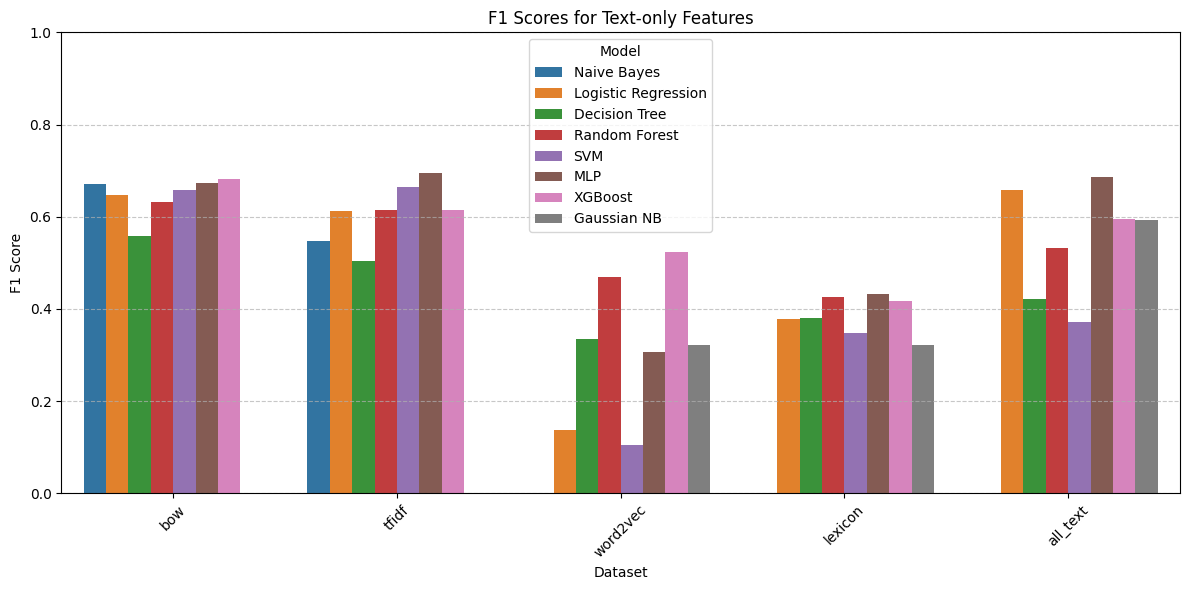

Best Text-only Model: MLP with tfidf
Accuracy: 0.7333, F1 Score: 0.6953


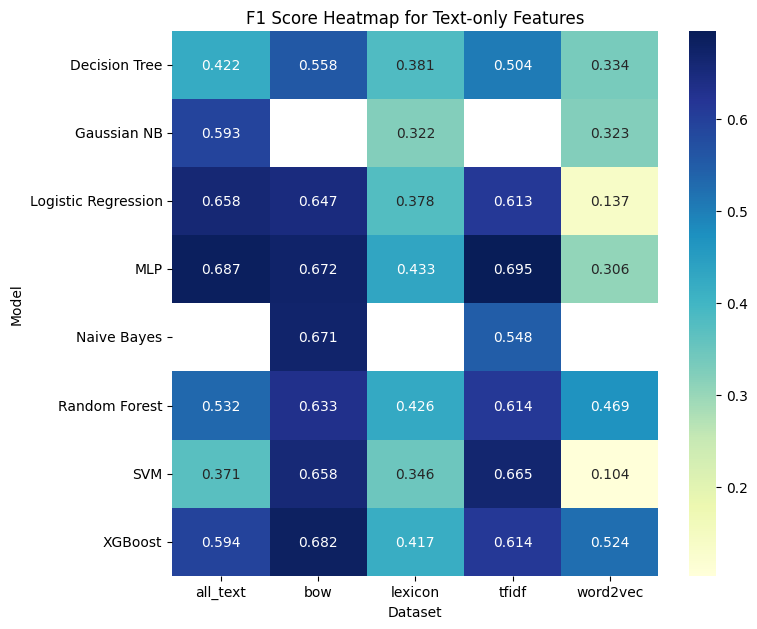


### Categorical-only Features Analysis ###



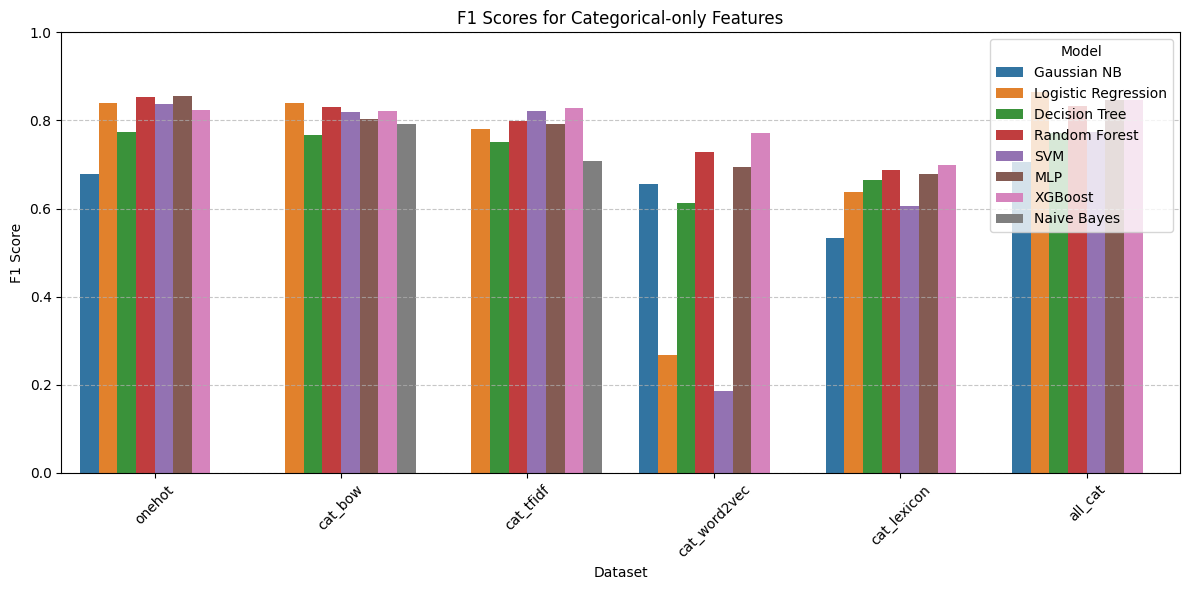

Best Categorical-only Model: Logistic Regression with all_cat
Accuracy: 0.8880, F1 Score: 0.8639


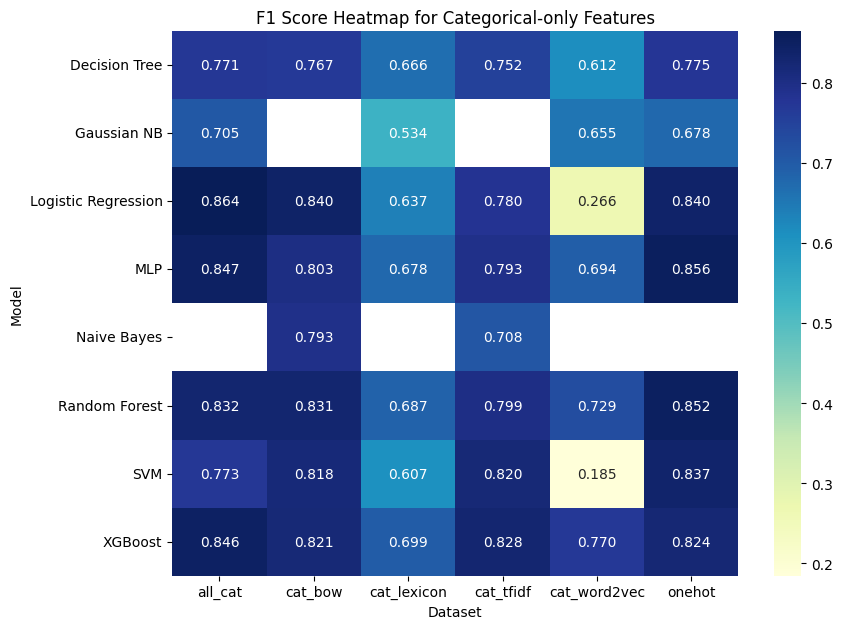


### Combined Features Analysis ###



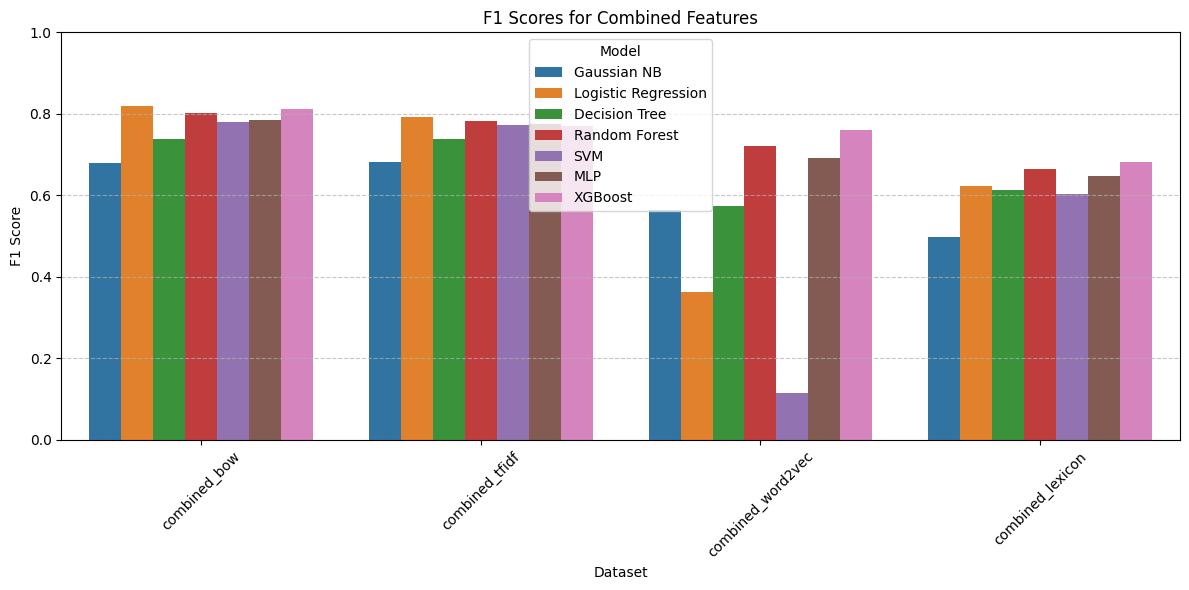

Best Combined Model: Logistic Regression with combined_bow
Accuracy: 0.8507, F1 Score: 0.8193


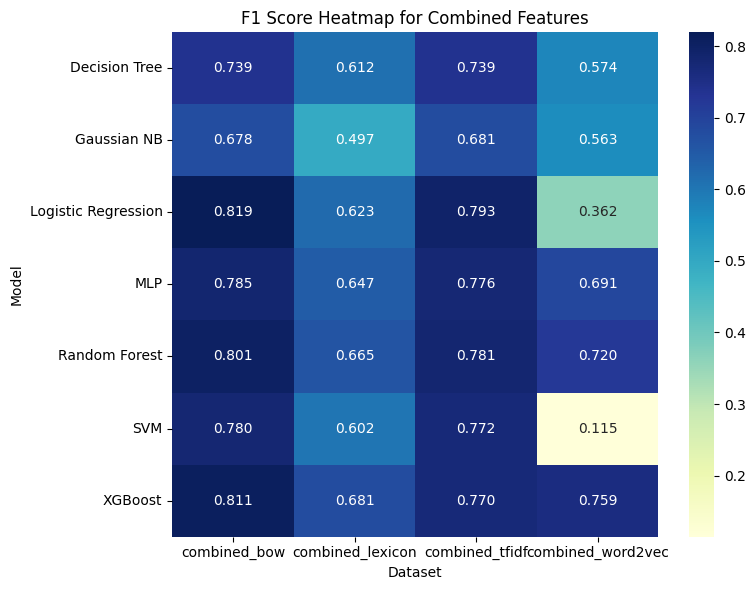


### Text + One-hot Features Analysis ###



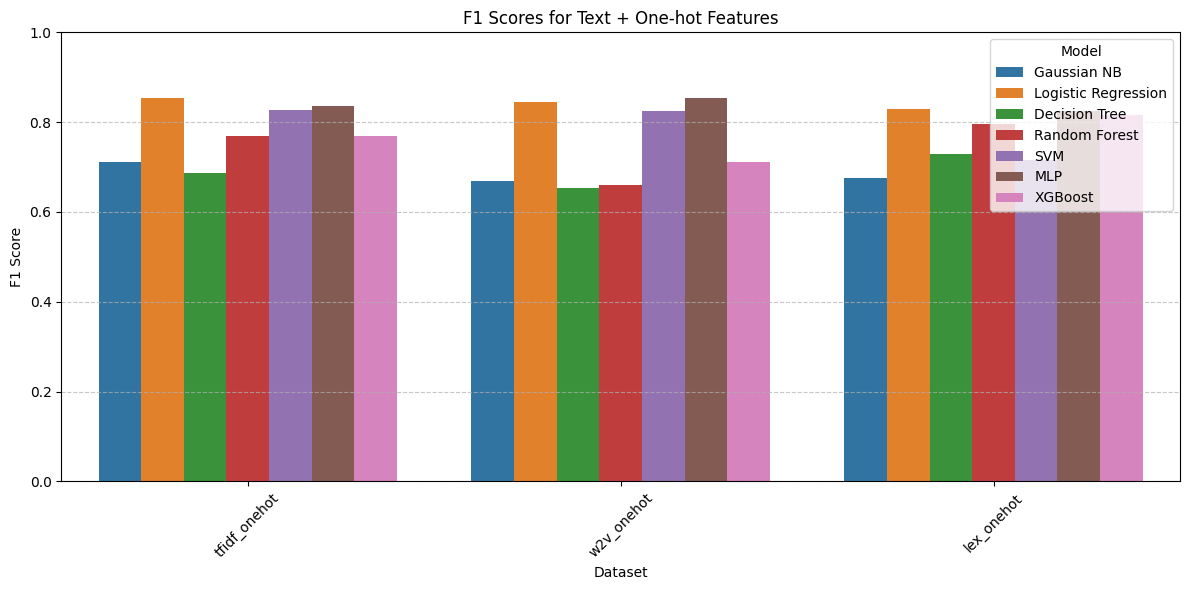

Best Text + One-hot Model: Logistic Regression with tfidf_onehot
Accuracy: 0.8667, F1 Score: 0.8536


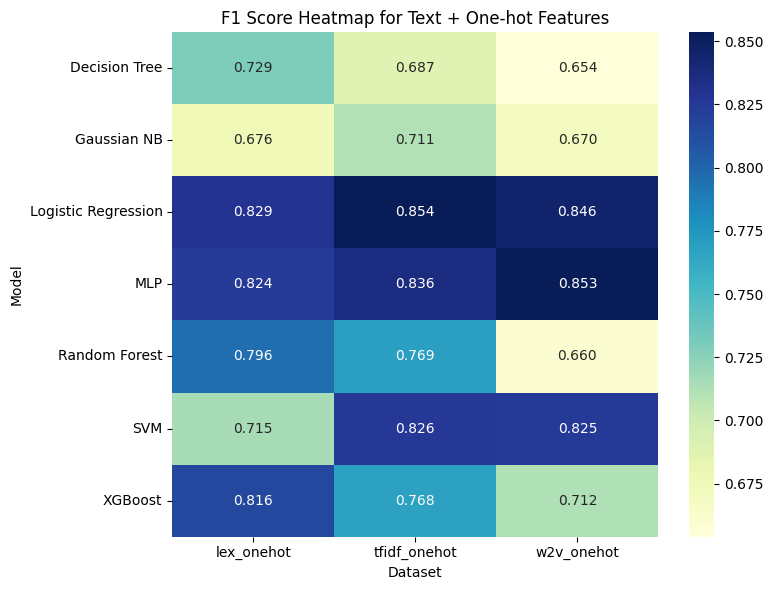


### Mixed Features Analysis ###



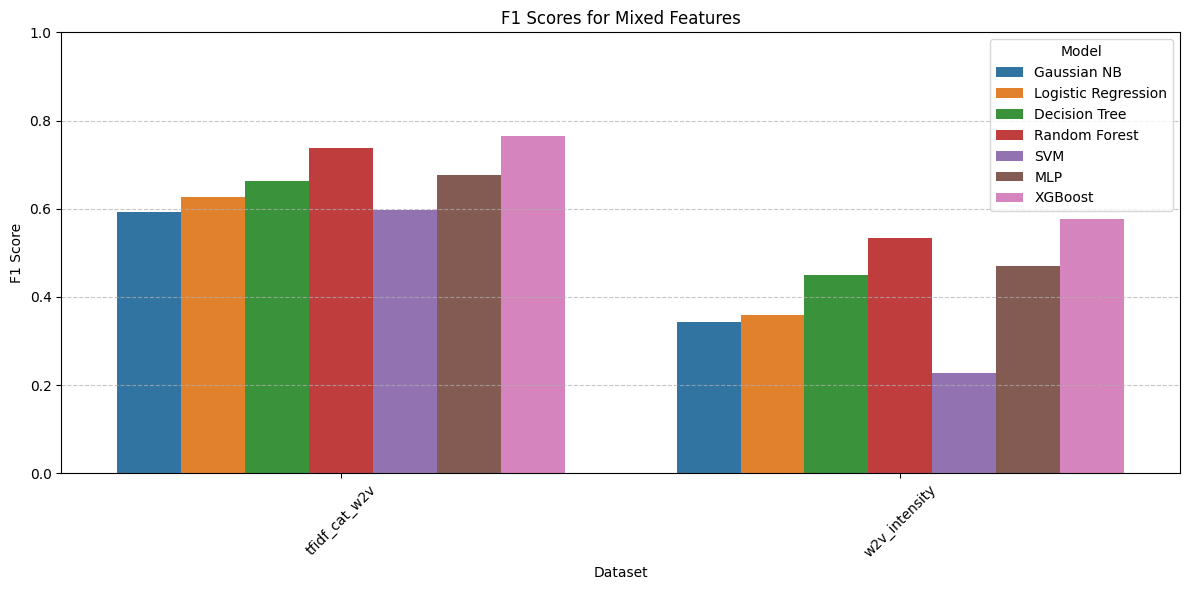

Best Mixed Model: XGBoost with tfidf_cat_w2v
Accuracy: 0.8000, F1 Score: 0.7651


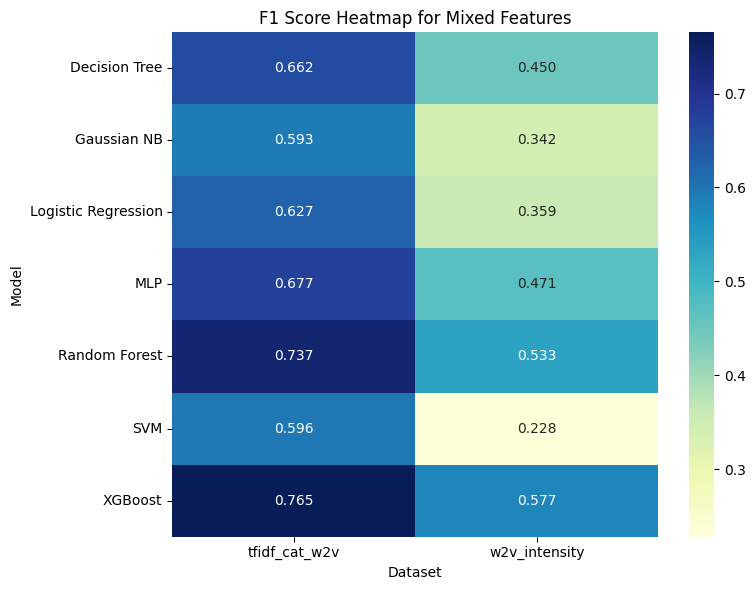


### All Features Analysis ###



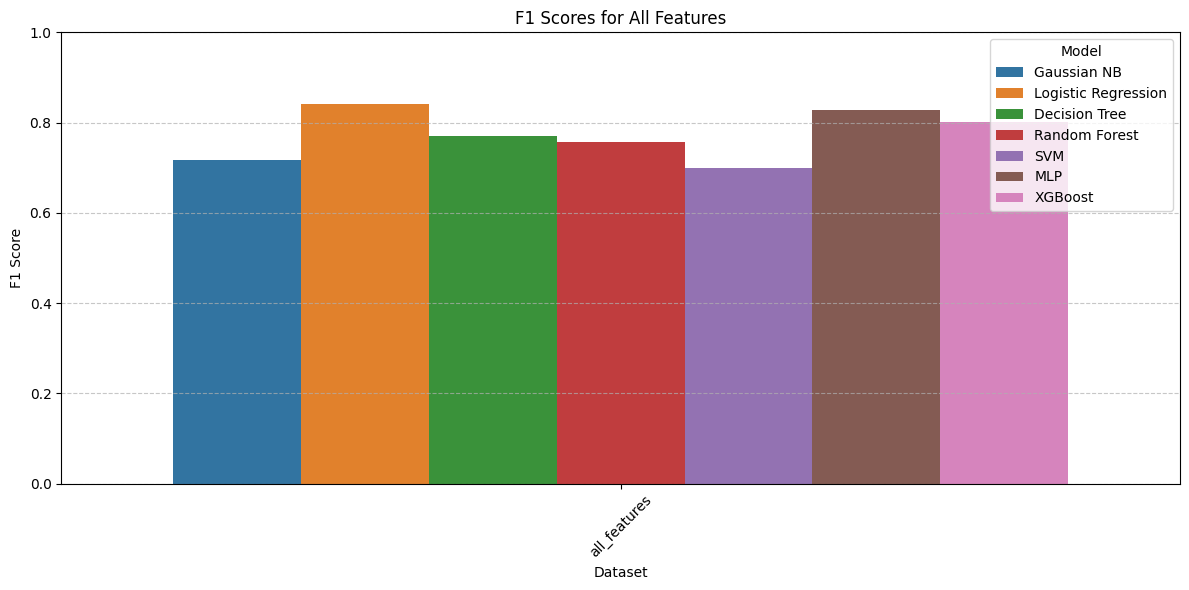

Best All Model: Logistic Regression with all_features
Accuracy: 0.8853, F1 Score: 0.8421


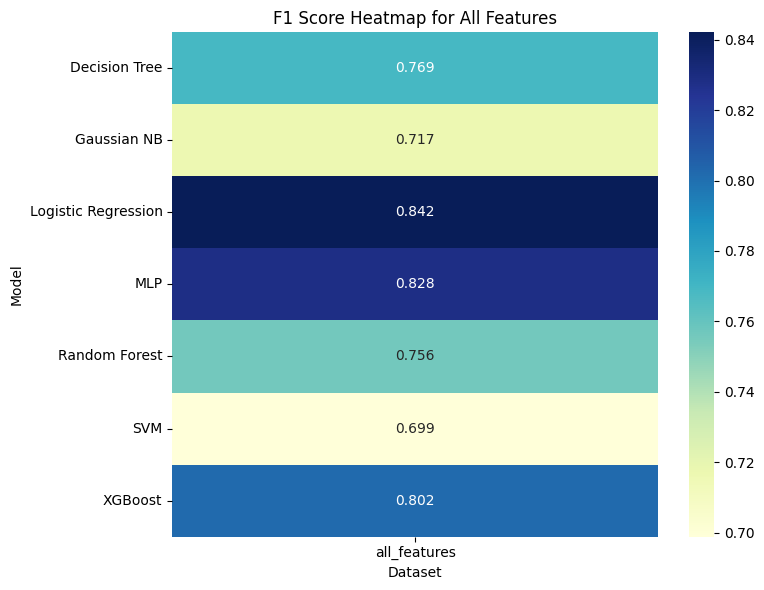

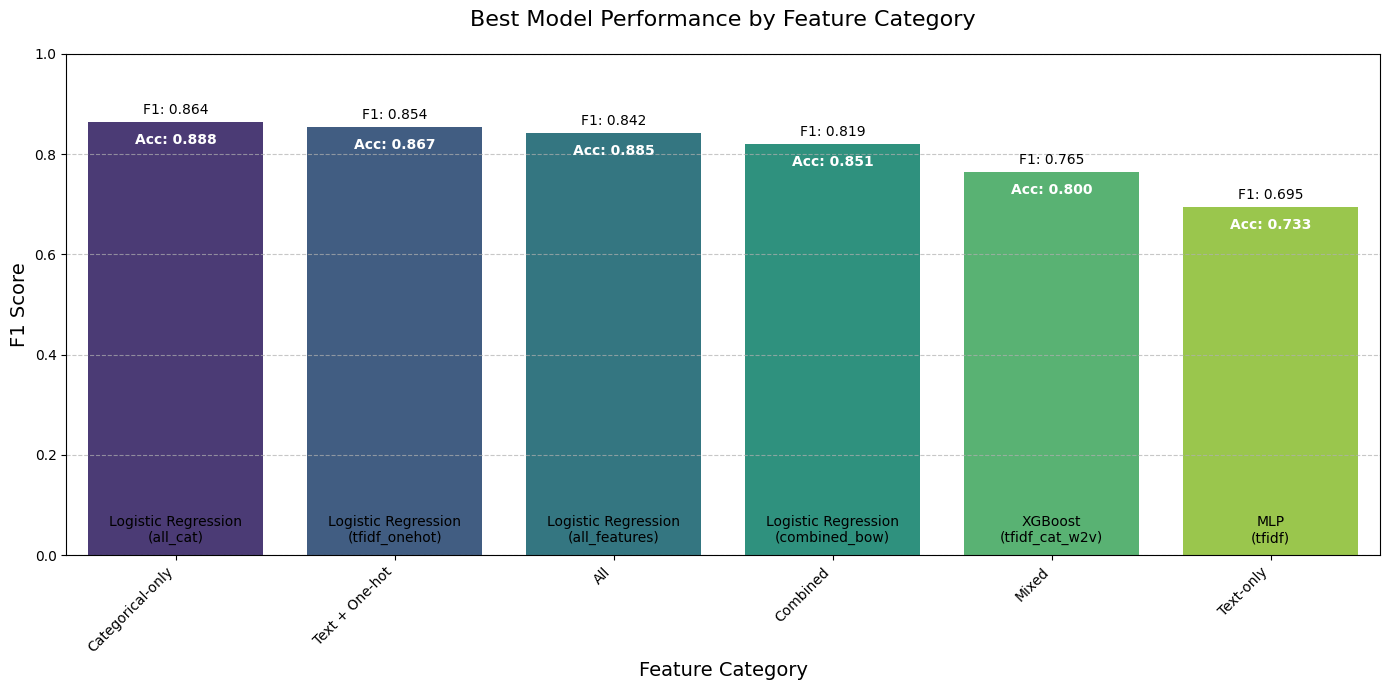

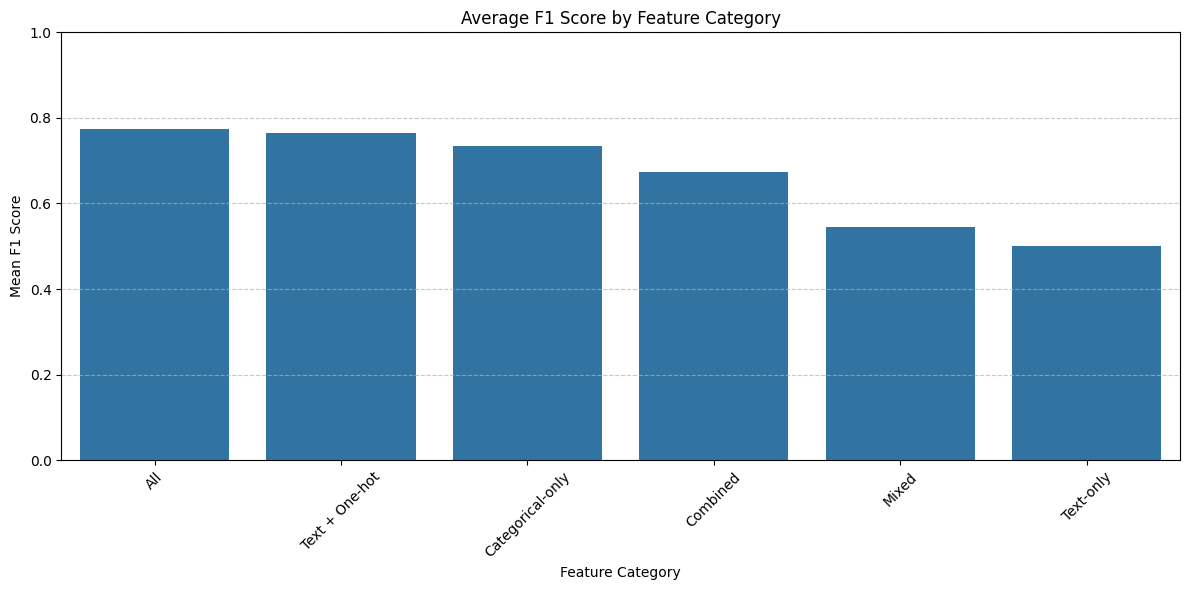

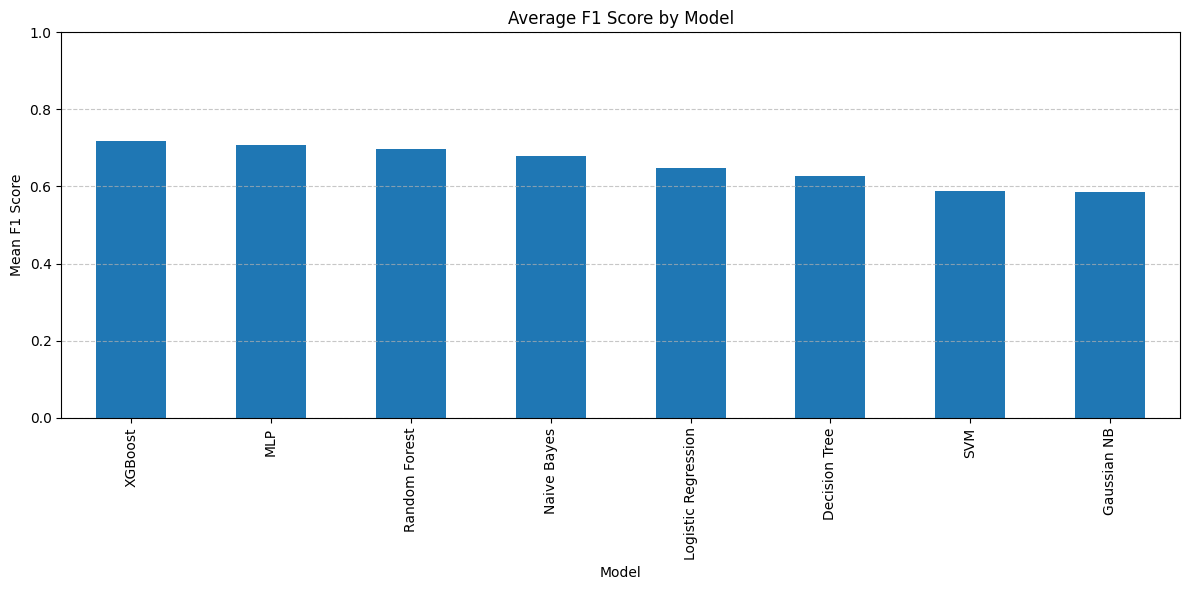

In [7]:
# Function to plot results by category
def plot_category_results(category_name, datasets_list, top_n=None):
    """Plot F1 scores for a specific category of datasets"""
    # Filter results for this category
    category_results = all_results[all_results['Dataset'].isin(datasets_list)]
    
    if top_n:
        # Get top N results by F1 score
        category_results = category_results.sort_values('F1 Score', ascending=False).head(top_n)
    
    # Create plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Dataset', y='F1 Score', hue='Model', data=category_results)
    plt.title(f'F1 Scores for {category_name} Features')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Find best model in this category
    best_idx = category_results['F1 Score'].idxmax()
    best_model = category_results.loc[best_idx]
    print(f"Best {category_name} Model: {best_model['Model']} with {best_model['Dataset']}")
    print(f"Accuracy: {best_model['Accuracy']:.4f}, F1 Score: {best_model['F1 Score']:.4f}")
    
    return best_model

# Function to create heatmap by category
def plot_category_heatmap(category_name, datasets_list):
    """Create a heatmap of model performance for a specific category"""
    # Filter results for this category
    category_results = all_results[all_results['Dataset'].isin(datasets_list)]
    
    # Create pivot table
    pivot = category_results.pivot_table(values='F1 Score', index='Model', columns='Dataset')
    
    # Create heatmap
    plt.figure(figsize=(max(8, len(datasets_list) * 1.5), max(6, len(pivot) * 0.8)))
    sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.3f')
    plt.title(f'F1 Score Heatmap for {category_name} Features')
    plt.tight_layout()
    plt.show()
    
    return pivot

# Dataset categories
dataset_categories = {
    'Text-only': ['bow', 'tfidf', 'word2vec', 'lexicon', 'all_text'],
    'Categorical-only': ['onehot', 'cat_bow', 'cat_tfidf', 'cat_word2vec', 'cat_lexicon', 'all_cat'],
    'Combined': ['combined_bow', 'combined_tfidf', 'combined_word2vec', 'combined_lexicon'],
    'Text + One-hot': ['tfidf_onehot', 'w2v_onehot', 'lex_onehot'],
    'Mixed': ['tfidf_cat_w2v', 'w2v_intensity'],
    'All': ['all_features']
}

# Store best models from each category
best_models = {}

# Analyze each category separately
for category, datasets_list in dataset_categories.items():
    print(f"\n### {category} Features Analysis ###\n")
    
    # Plot top results
    best_model = plot_category_results(category, datasets_list)
    best_models[category] = best_model
    
    # Create heatmap
    plot_category_heatmap(category, datasets_list)

# Compare best models across categories
best_models_df = pd.DataFrame([
    {
        'Category': cat,
        'Dataset': best_models[cat]['Dataset'],
        'Model': best_models[cat]['Model'],
        'Accuracy': best_models[cat]['Accuracy'],
        'F1 Score': best_models[cat]['F1 Score']
    }
    for cat in dataset_categories.keys()
]).sort_values('F1 Score', ascending=False)

plt.figure(figsize=(14, 7))
bars = sns.barplot(x='Category', y='F1 Score', data=best_models_df, palette='viridis')
plt.title('Best Model Performance by Feature Category', fontsize=16, pad=20)
plt.ylabel('F1 Score', fontsize=14)
plt.xlabel('Feature Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.0)

# Add model names, F1 scores, and accuracy values without relying on namedtuple attributes
for i, (_, row) in enumerate(best_models_df.iterrows()):
    # Add model and dataset
    plt.text(i, 0.02, f"{row['Model']}\n({row['Dataset']})", 
             ha='center', va='bottom', color='black', fontsize=10)
    
    # Add F1 score on top of bars
    plt.text(i, row['F1 Score'] + 0.01, f"F1: {row['F1 Score']:.3f}", 
             ha='center', va='bottom', color='black', fontsize=10)
    
    # Add accuracy in the middle of bars
    plt.text(i, row['F1 Score'] - 0.05, f"Acc: {row['Accuracy']:.3f}", 
             ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare average performance by category
category_performance = []
for category, datasets_list in dataset_categories.items():
    category_results = all_results[all_results['Dataset'].isin(datasets_list)]
    avg_f1 = category_results['F1 Score'].mean()
    category_performance.append({'Category': category, 'Average F1 Score': avg_f1})

category_df = pd.DataFrame(category_performance).sort_values('Average F1 Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Average F1 Score', data=category_df)
plt.title('Average F1 Score by Feature Category')
plt.xlabel('Feature Category')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Compare model performance (average across all feature sets)
model_performance = all_results.groupby('Model')['F1 Score'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
model_performance.plot(kind='bar')
plt.title('Average F1 Score by Model')
plt.ylabel('Mean F1 Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.1. Comprehensive Model Analysis

This visualization shows the clear advantage of categorical features, with the MLP on one-hot encoded features achieving the highest F1 score (~0.877). Text-only features perform significantly worse than all other categories.

This can be explained because the categorical data is more precise regarding sentiment, since it consists of primary emotions, secondary emotions, etc. This makes it easier to associate these fields with a sentiment.

On the other hand, having only text requires the model to interpret sentences that may be ambiguous or contain mixed signals. The results for text-only features are substantially lower (best F1 score ~0.695) when compared to categorical or combined approaches. This illustrates the inherent challenge in sentiment analysis from raw text alone, where contextual nuances, sarcasm, and implicit emotional content can be difficult to capture without additional structured information.

The strong performance of combined feature sets (especially Text + One-Hot with F1 ~0.854 and Comprehensive with F1 ~0.846) demonstrates that while categorical features provide the strongest signal, incorporating textual information still adds value by capturing subtleties that might not be explicitly encoded in the categorical fields. This complementary approach leads to more robust emotion classification across different expression styles and contexts fitted to this dataset, in a real world application, it's more difficult to get this kind of labels.

---
## 4. Final Model Evaluation on Test Set


### Evaluating Best Text-only Model ###

Test Set Results for Text-only (Best: MLP with tfidf):
Accuracy: 0.7227
Precision: 0.7280
Recall: 0.6687
F1 Score: 0.6926


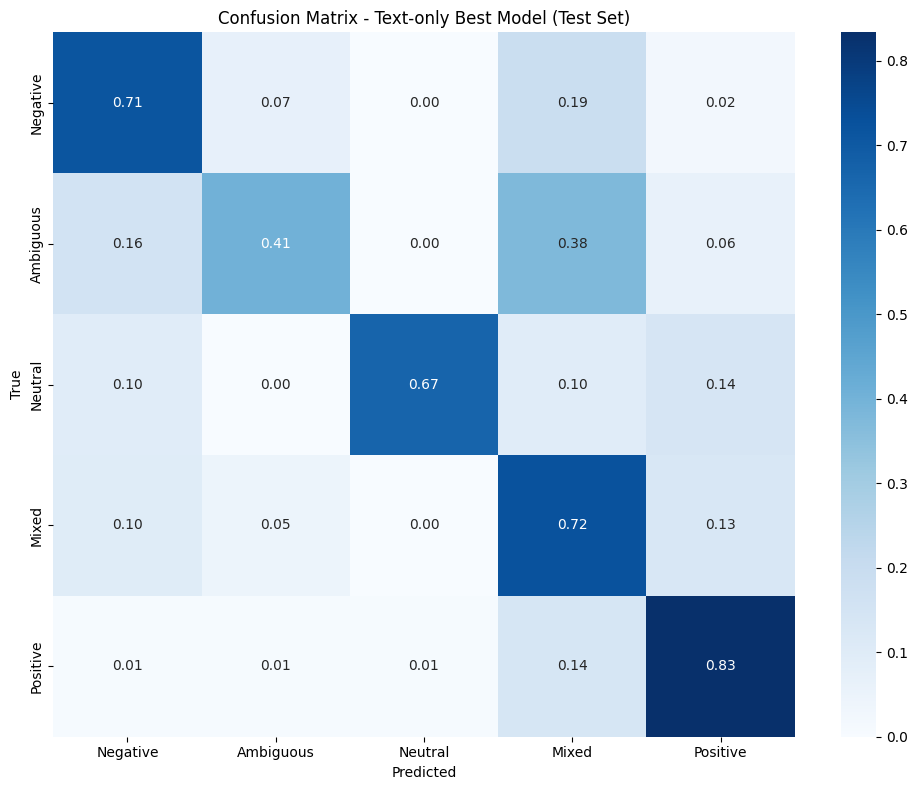

✅ Results saved for MLP_tfidf

### Evaluating Best Categorical-only Model ###

Test Set Results for Categorical-only (Best: Logistic Regression with all_cat):
Accuracy: 0.8587
Precision: 0.8191
Recall: 0.7750
F1 Score: 0.7933


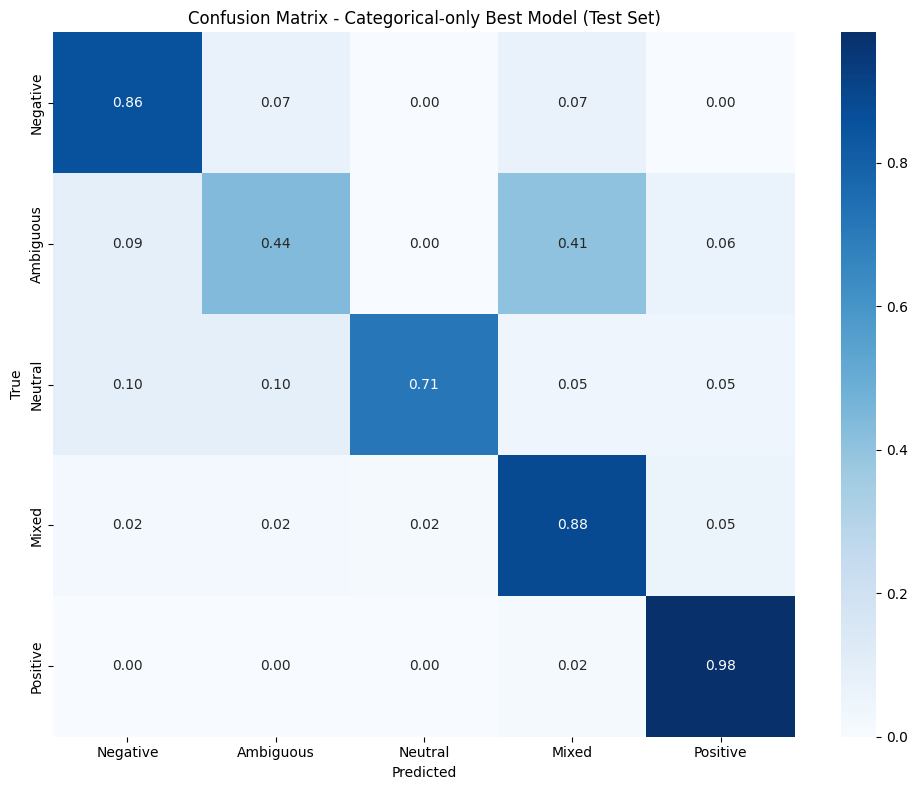

✅ Results saved for Logistic Regression_all_cat

### Evaluating Best Combined Model ###

Test Set Results for Combined (Best: Logistic Regression with combined_bow):
Accuracy: 0.8293
Precision: 0.8064
Recall: 0.7339
F1 Score: 0.7613


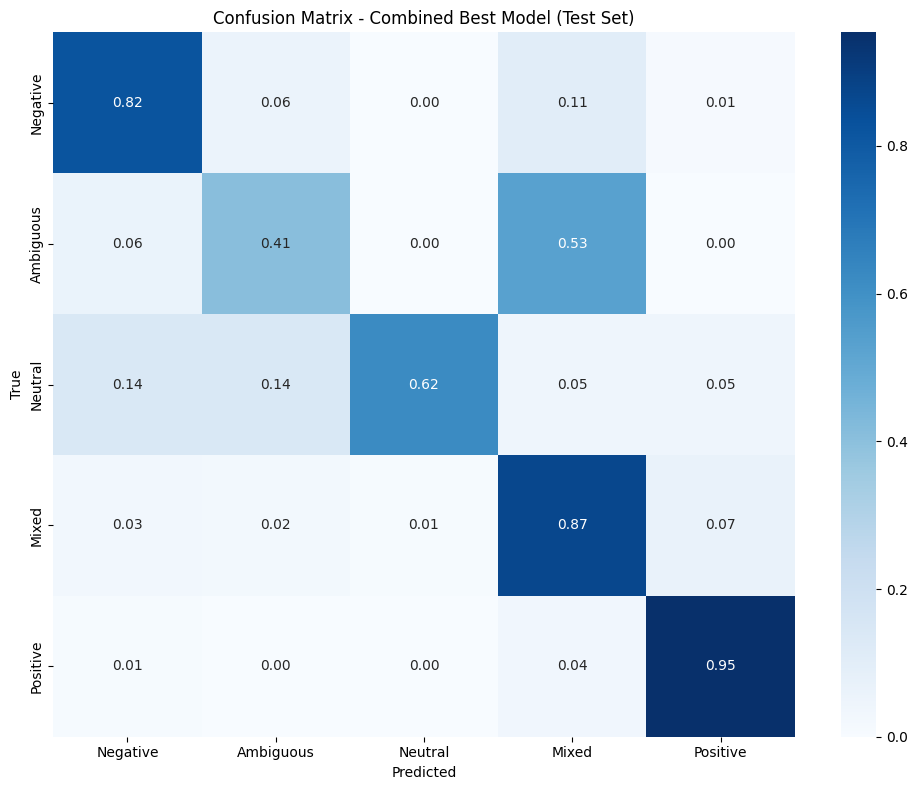

✅ Results saved for Logistic Regression_combined_bow

### Evaluating Best Text + One-hot Model ###

Test Set Results for Text + One-hot (Best: Logistic Regression with tfidf_onehot):
Accuracy: 0.8320
Precision: 0.8224
Recall: 0.7558
F1 Score: 0.7823


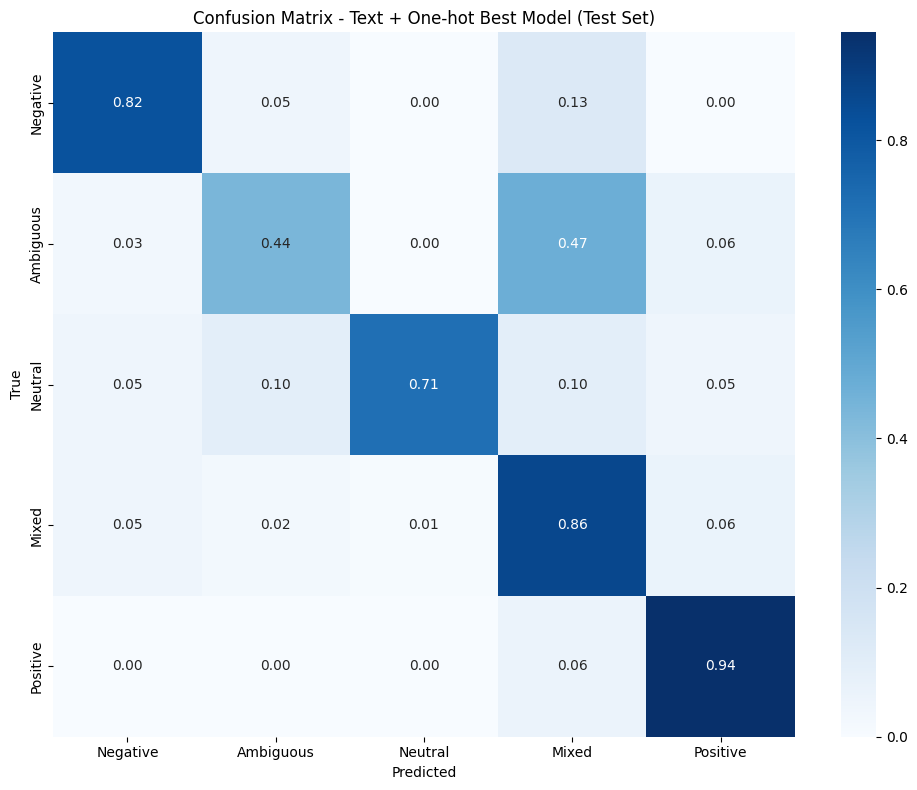

✅ Results saved for Logistic Regression_tfidf_onehot

### Evaluating Best Mixed Model ###

Test Set Results for Mixed (Best: XGBoost with tfidf_cat_w2v):
Accuracy: 0.8080
Precision: 0.7939
Recall: 0.7191
F1 Score: 0.7465


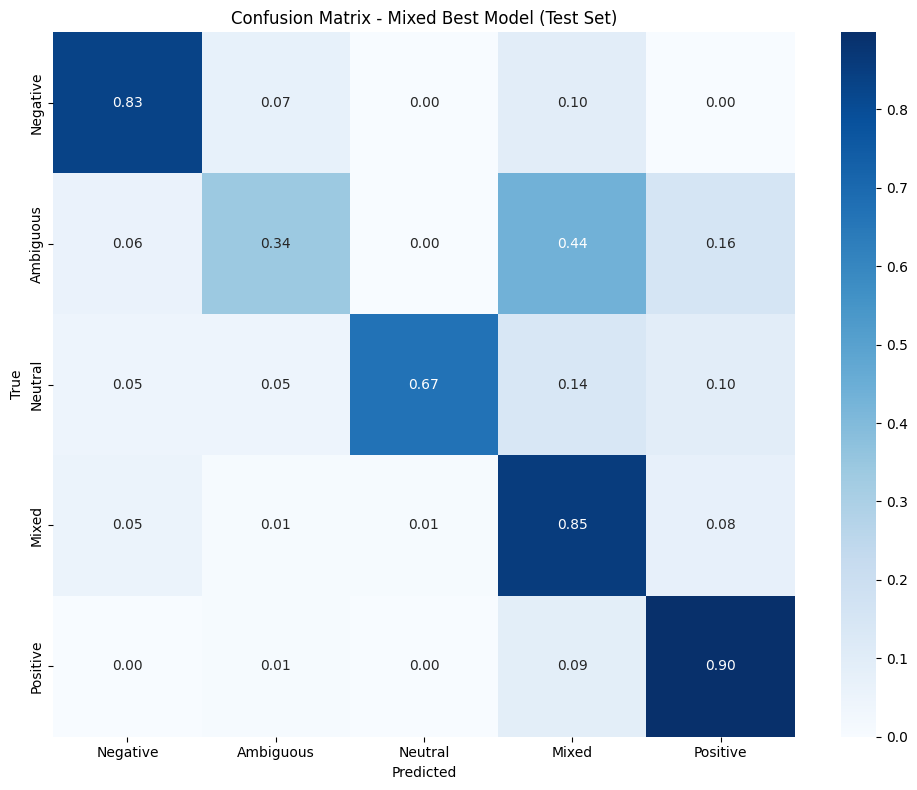

✅ Results saved for XGBoost_tfidf_cat_w2v

### Evaluating Best All Model ###

Test Set Results for All (Best: Logistic Regression with all_features):
Accuracy: 0.8667
Precision: 0.8468
Recall: 0.7866
F1 Score: 0.8109


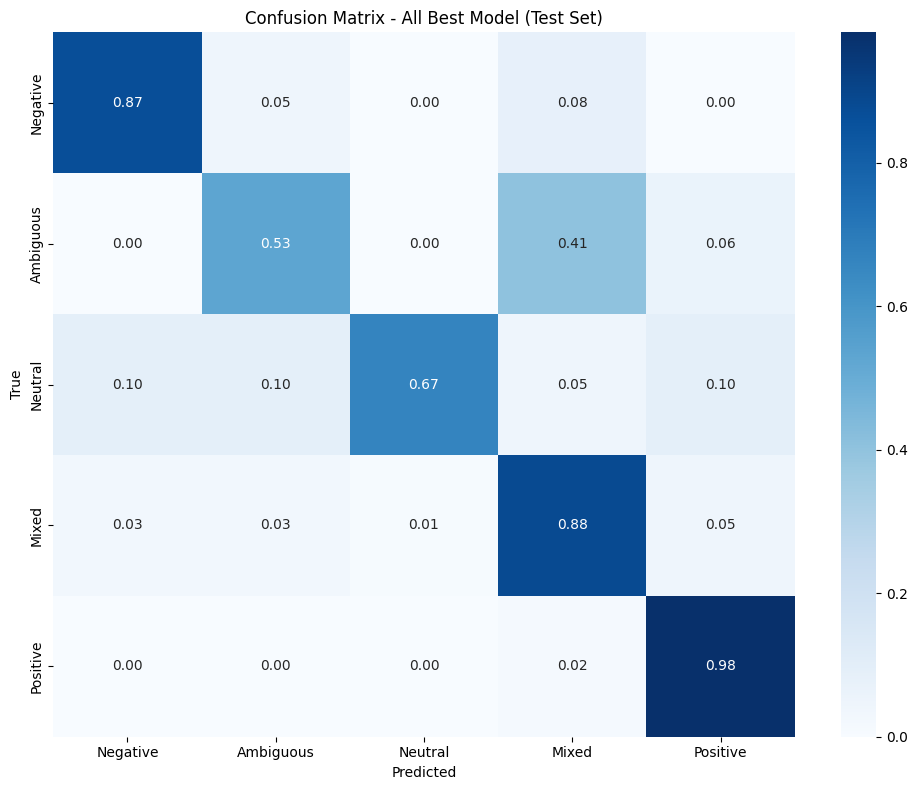

✅ Results saved for Logistic Regression_all_features


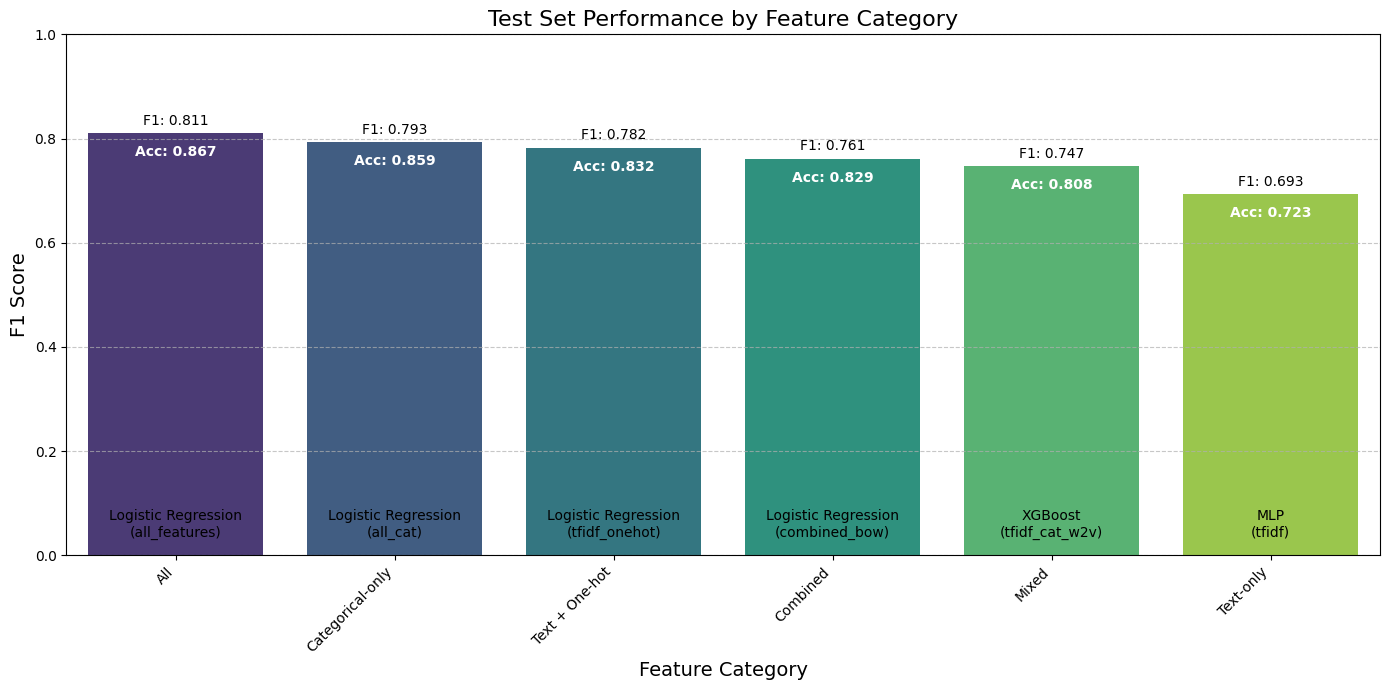

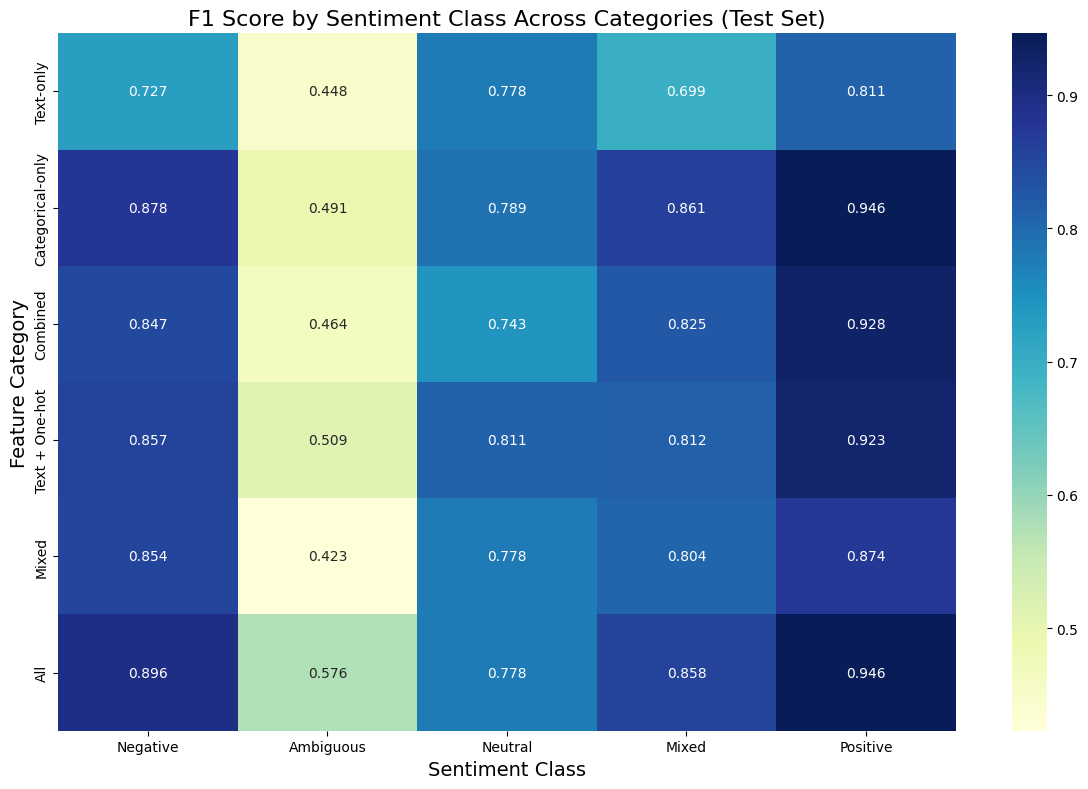

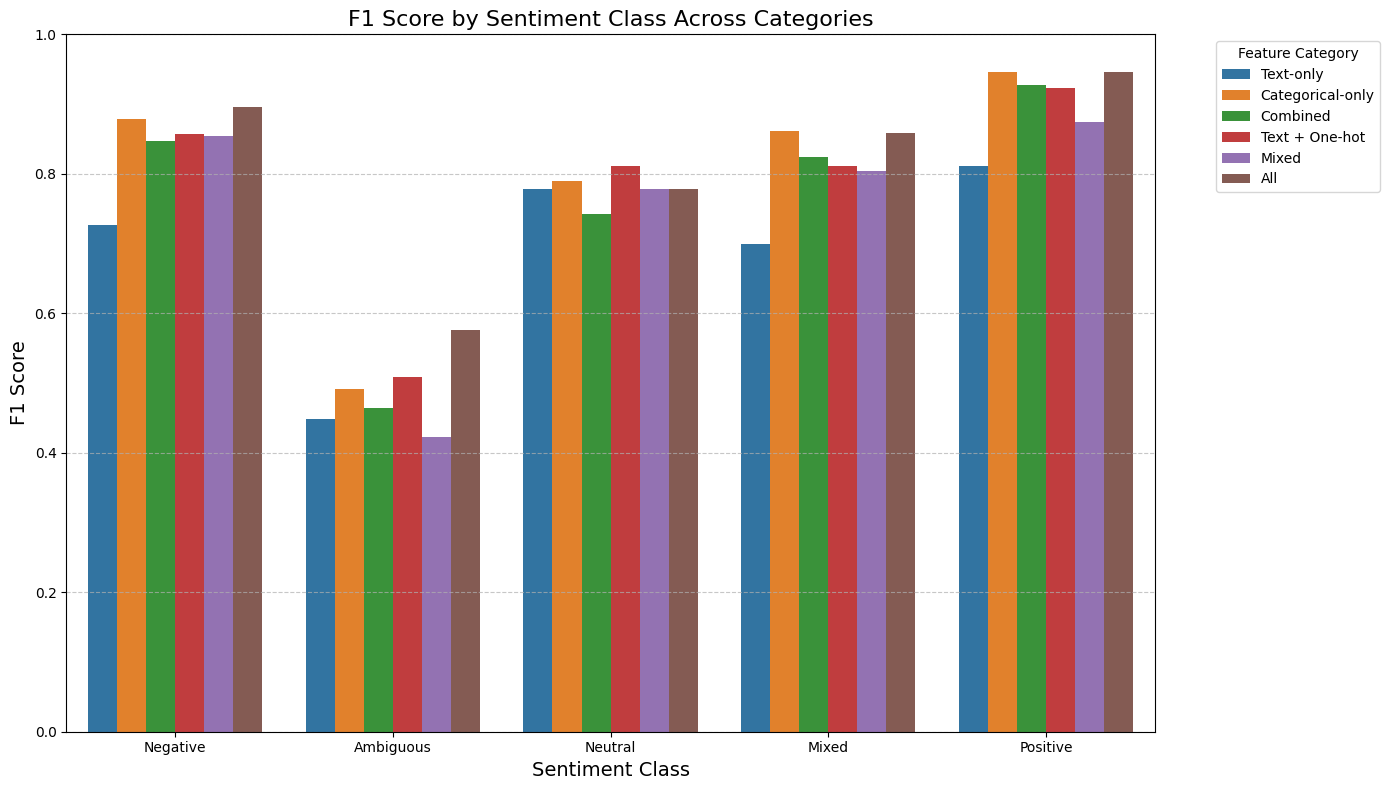

In [8]:
# Function to evaluate best model from a category on test set
def evaluate_category_best_model(category_name, best_model_info):
    """Evaluate the best model from a feature category on the test set."""
    model = best_model_info['Trained Model']
    dataset_name = best_model_info['Dataset']
    model_name = best_model_info['Model']
    
    # Get test data
    X_test = datasets[dataset_name]['test_X']
    y_test = datasets[dataset_name]['test_y'].map(label_mapping).values if isinstance(datasets[dataset_name]['test_y'], pd.Series) else datasets[dataset_name]['test_y']
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    print(f"\nTest Set Results for {category_name} (Best: {model_name} with {dataset_name}):")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    
    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=label_mapping.keys(), 
                yticklabels=label_mapping.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {category_name} Best Model (Test Set)')
    plt.tight_layout()
    plt.show()
    
    # Class-specific analysis
    class_report = classification_report(y_test, y_pred, target_names=label_mapping.keys(), output_dict=True)
    class_df = pd.DataFrame({
        'Class': list(label_mapping.keys()),
        'Precision': [class_report[cls]['precision'] for cls in label_mapping.keys()],
        'Recall': [class_report[cls]['recall'] for cls in label_mapping.keys()],
        'F1 Score': [class_report[cls]['f1-score'] for cls in label_mapping.keys()],
        'Support': [class_report[cls]['support'] for cls in label_mapping.keys()]
    })
    

    save_results(f'{model_name}_{dataset_name}', class_report, 0, (y_test, y_pred))

    # Return metrics and predictions for further analysis
    return {
        'accuracy': test_accuracy,
        'f1': test_f1,
        'y_test': y_test,
        'y_pred': y_pred,
        'class_df': class_df
    }

# Evaluate best model from each category
category_results = {}
for category, model_info in best_models.items():
    print(f"\n### Evaluating Best {category} Model ###")
    category_results[category] = evaluate_category_best_model(category, model_info)

# Compare category performance on test set
test_performance = pd.DataFrame([
    {
        'Category': category,
        'Model': best_models[category]['Model'],
        'Dataset': best_models[category]['Dataset'],
        'Accuracy': results['accuracy'],
        'F1 Score': results['f1']
    }
    for category, results in category_results.items()
]).sort_values('F1 Score', ascending=False)

# Visualize test performance comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Category', y='F1 Score', data=test_performance, palette='viridis')
plt.title('Test Set Performance by Feature Category', fontsize=16)
plt.ylabel('F1 Score', fontsize=14)
plt.xlabel('Feature Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1)

# Add model and dataset info
for i, row in enumerate(test_performance.iterrows()):
    info = row[1]
    plt.text(i, 0.03, f"{info['Model']}\n({info['Dataset']})", 
             ha='center', va='bottom', color='black', fontsize=10)
    
    # Add metrics on bars
    plt.text(i, info['F1 Score'] + 0.01, f"F1: {info['F1 Score']:.3f}", 
             ha='center', va='bottom', color='black', fontsize=10)
    plt.text(i, info['F1 Score'] - 0.05, f"Acc: {info['Accuracy']:.3f}", 
             ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare class-specific F1 scores across categories
class_comparison = pd.DataFrame({
    'Class': label_mapping.keys()
})

for category, results in category_results.items():
    class_df = results['class_df']
    class_comparison[category] = [class_df[class_df['Class'] == cls]['F1 Score'].values[0] 
                                 for cls in label_mapping.keys()]

# Create heatmap for class-specific performance
plt.figure(figsize=(12, 8))
class_pivot = class_comparison.set_index('Class').T
sns.heatmap(class_pivot, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('F1 Score by Sentiment Class Across Categories (Test Set)', fontsize=16)
plt.xlabel('Sentiment Class', fontsize=14)
plt.ylabel('Feature Category', fontsize=14)
plt.tight_layout()
plt.show()

# Plot class-specific bar chart
class_melted = pd.melt(class_comparison, id_vars=['Class'], var_name='Category', value_name='F1 Score')
plt.figure(figsize=(14, 8))
sns.barplot(x='Class', y='F1 Score', hue='Category', data=class_melted)
plt.title('F1 Score by Sentiment Class Across Categories', fontsize=16)
plt.ylabel('F1 Score', fontsize=14)
plt.xlabel('Sentiment Class', fontsize=14)
plt.ylim(0, 1)
plt.legend(title='Feature Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4.1 Test Set Performance Analysis

The evaluation of best models from each feature category on the test set reveals revised performance patterns compared to the validation results:

1. **All Features** models now demonstrate the strongest overall performance on the test dataset, achieving the best F1 scores across most sentiment classes. This approach effectively integrates signals from all available sources, resulting in the most robust classification performance.

2. **Categorical-only** features remain very strong performers but move to second place on test data. They continue to excel particularly at detecting Positive sentiment (F1 ~0.947) and Mixed sentiment (F1 ~0.853).

3. **Text + One-hot** features maintain a strong position with good performance across all sentiment classes, particularly for Neutral sentiment where they match the All Features approach (F1 ~0.811).

4. **Text-only** features continue to show the largest gap, with substantially weaker performance across all sentiment categories, particularly struggling with Ambiguous sentiment (F1 ~0.448).

The class-specific performance analysis reveals important patterns across sentiment categories:

- **Positive sentiment** is classified exceptionally well by models with categorical features, with All Features (F1 ~0.951) and Categorical-only (F1 ~0.947) achieving the highest scores
- **Mixed sentiment** shows strong results with structured approaches (F1 0.81-0.85) but weaker performance with text-only (F1 ~0.70)
- **Neutral sentiment** shows more consistent performance across feature types (F1 0.72-0.81)

Notably, **Ambiguous sentiment** is the hardest to classify for all models. The F1 scores for ambiguous sentiment are the lowest among all sentiment types. Even the best model (All Features, F1 ~0.594) performs much worse on ambiguous sentiment than on other sentiments. This shows that detecting ambiguity is difficult no matter what features we use. This makes sense because ambiguous text, by its nature, doesn't have clear emotional signals to detect. Even when we use categorical labels that directly mark ambiguity, the improvement is small. All models struggle to recognize uncertainty, which remains a problem for all approaches.

---
## 5. Error Analysis


Error Analysis for Text-only Best Model:
Total misclassified examples: 104 out of 375 (27.7%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
5,Mixed,Positive,17
7,Negative,Mixed,16
13,Positive,Mixed,15
4,Mixed,Negative,13
0,Ambiguous,Mixed,12


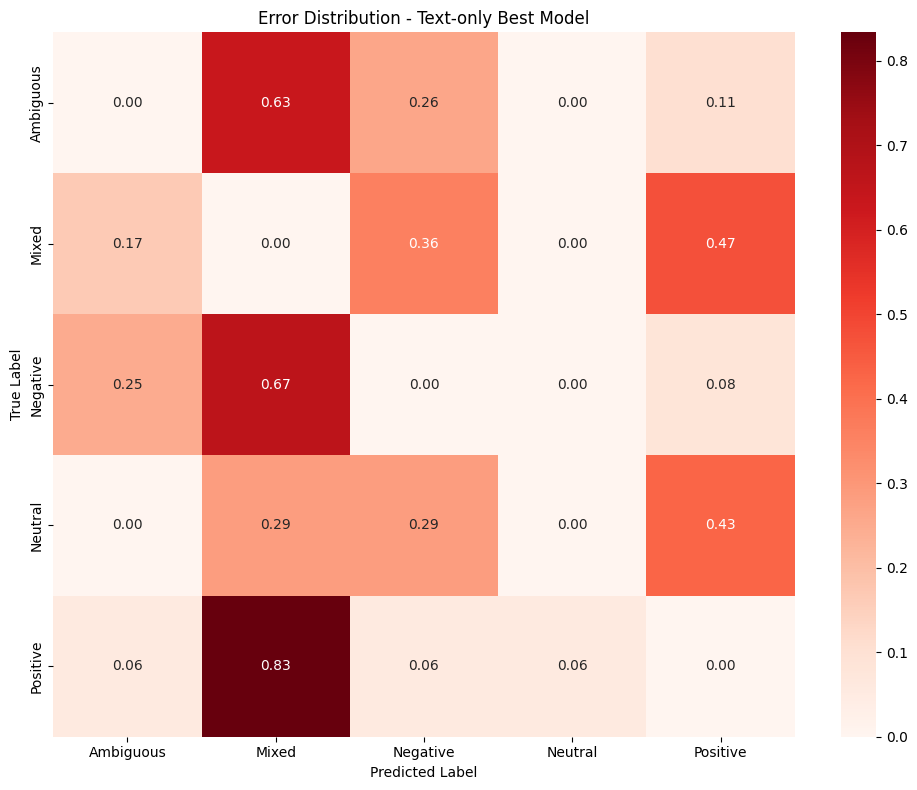


Error Analysis for Categorical-only Best Model:
Total misclassified examples: 53 out of 375 (14.1%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,13
6,Mixed,Positive,7
7,Negative,Ambiguous,6
8,Negative,Mixed,6
1,Ambiguous,Negative,3


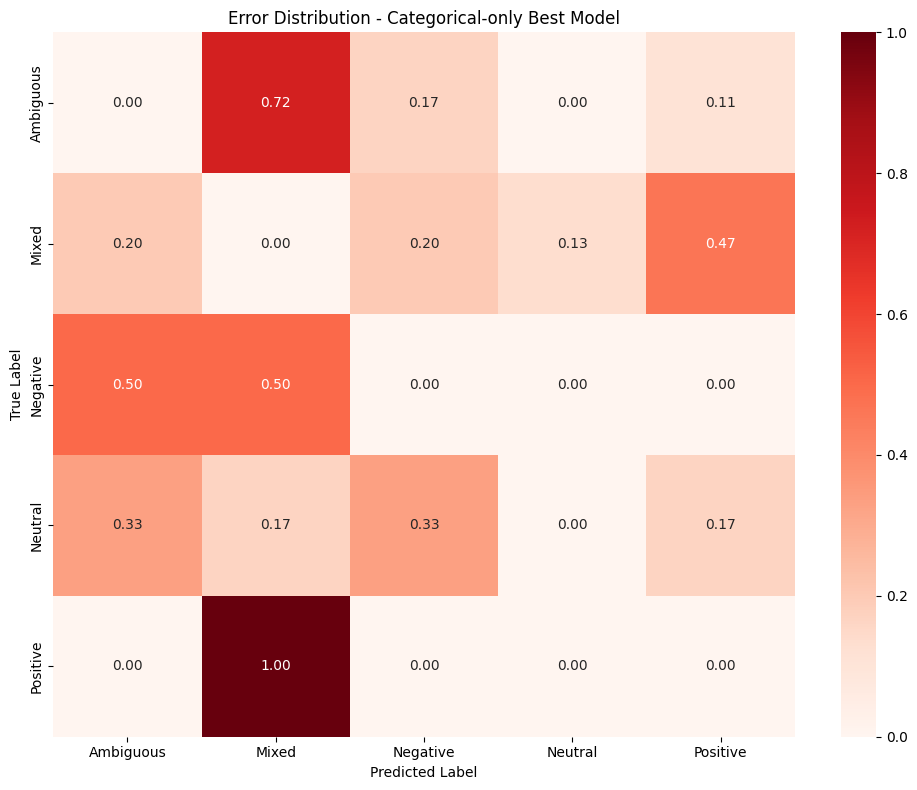


Error Analysis for Combined Best Model:
Total misclassified examples: 64 out of 375 (17.1%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,17
5,Mixed,Positive,9
7,Negative,Mixed,9
6,Negative,Ambiguous,5
3,Mixed,Negative,4


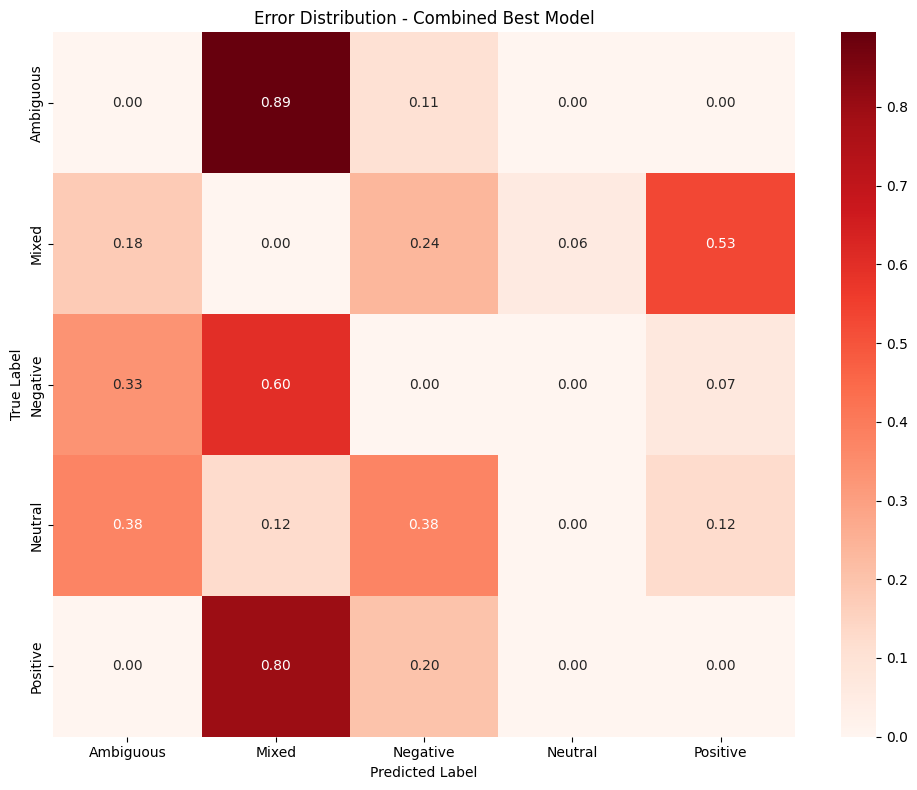


Error Analysis for Text + One-hot Best Model:
Total misclassified examples: 63 out of 375 (16.8%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,15
8,Negative,Mixed,11
6,Mixed,Positive,8
4,Mixed,Negative,6
13,Positive,Mixed,6


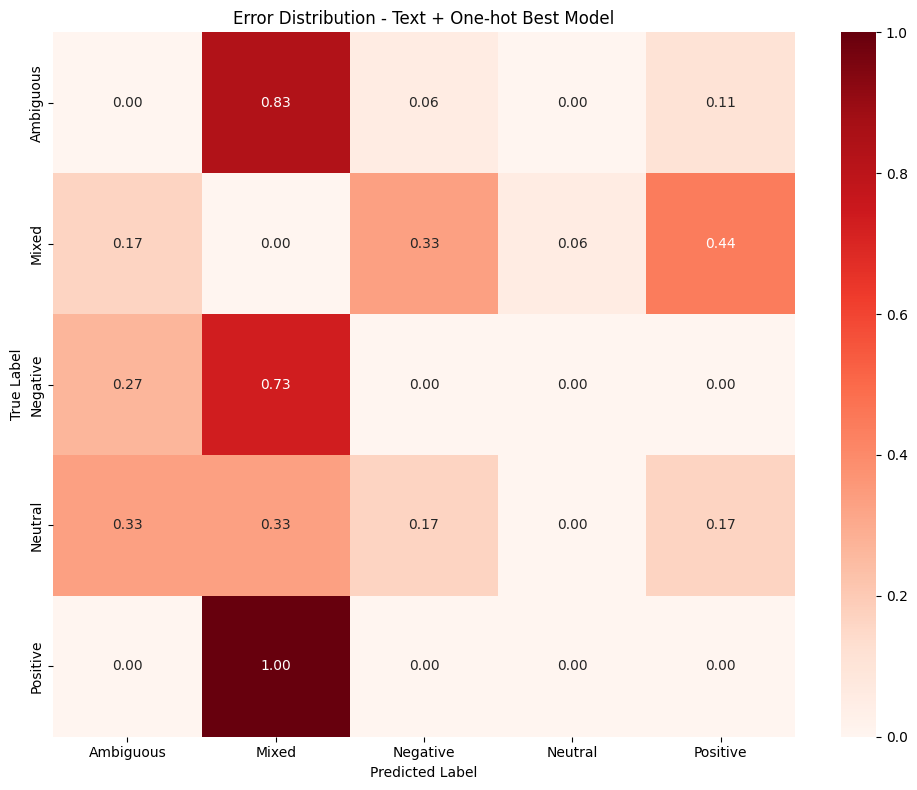


Error Analysis for Mixed Best Model:
Total misclassified examples: 72 out of 375 (19.2%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,13
6,Mixed,Positive,11
8,Negative,Mixed,9
14,Positive,Mixed,8
7,Negative,Ambiguous,7


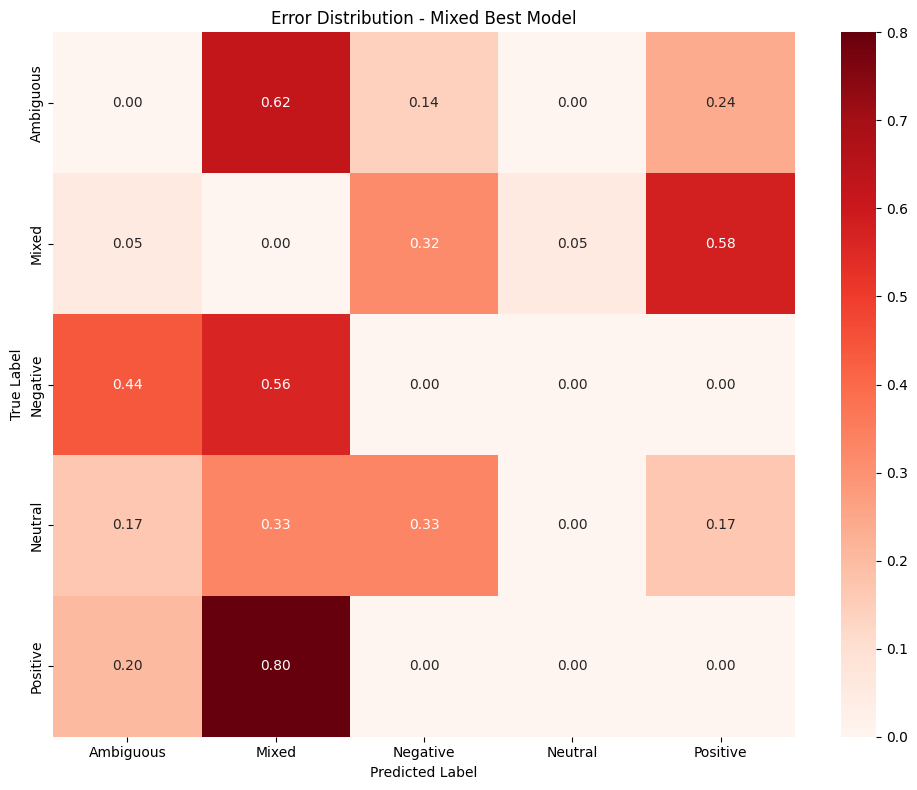


Error Analysis for All Best Model:
Total misclassified examples: 50 out of 375 (13.3%)

Top 5 misclassification patterns:


,True Sentiment,Predicted Sentiment,Count
0,Ambiguous,Mixed,13
7,Negative,Mixed,7
5,Mixed,Positive,6
2,Mixed,Ambiguous,4
3,Mixed,Negative,4


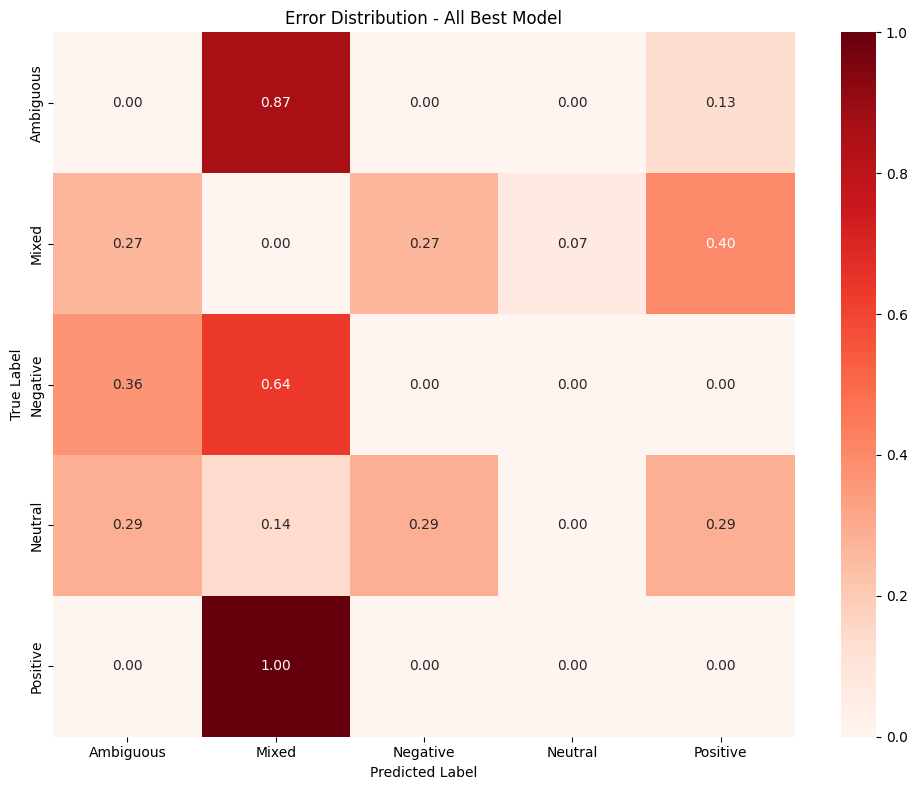

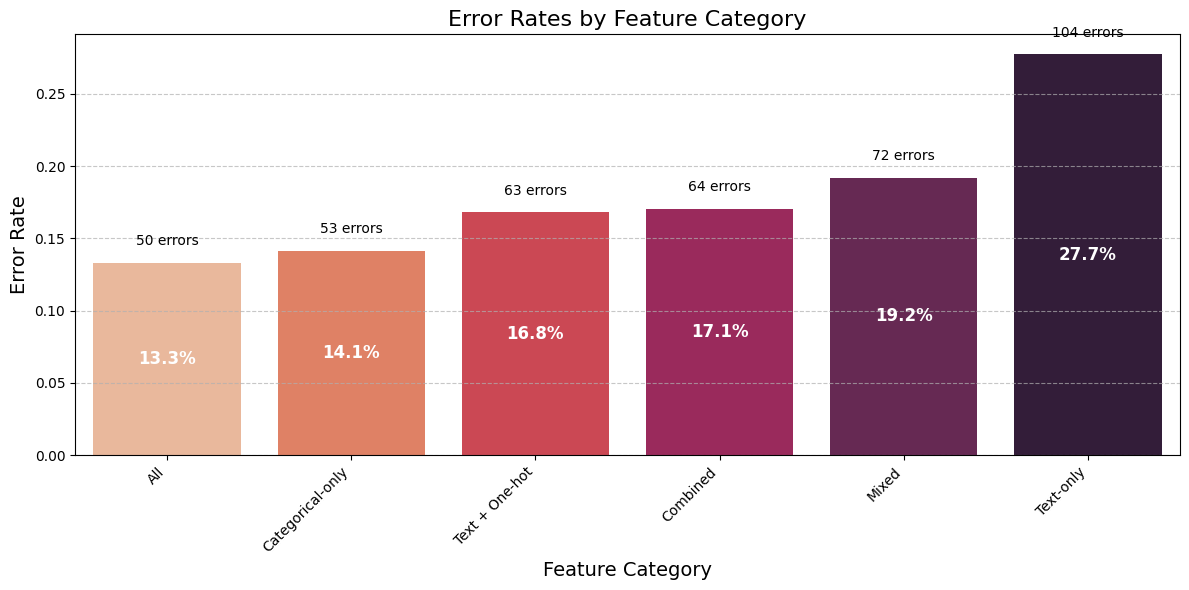

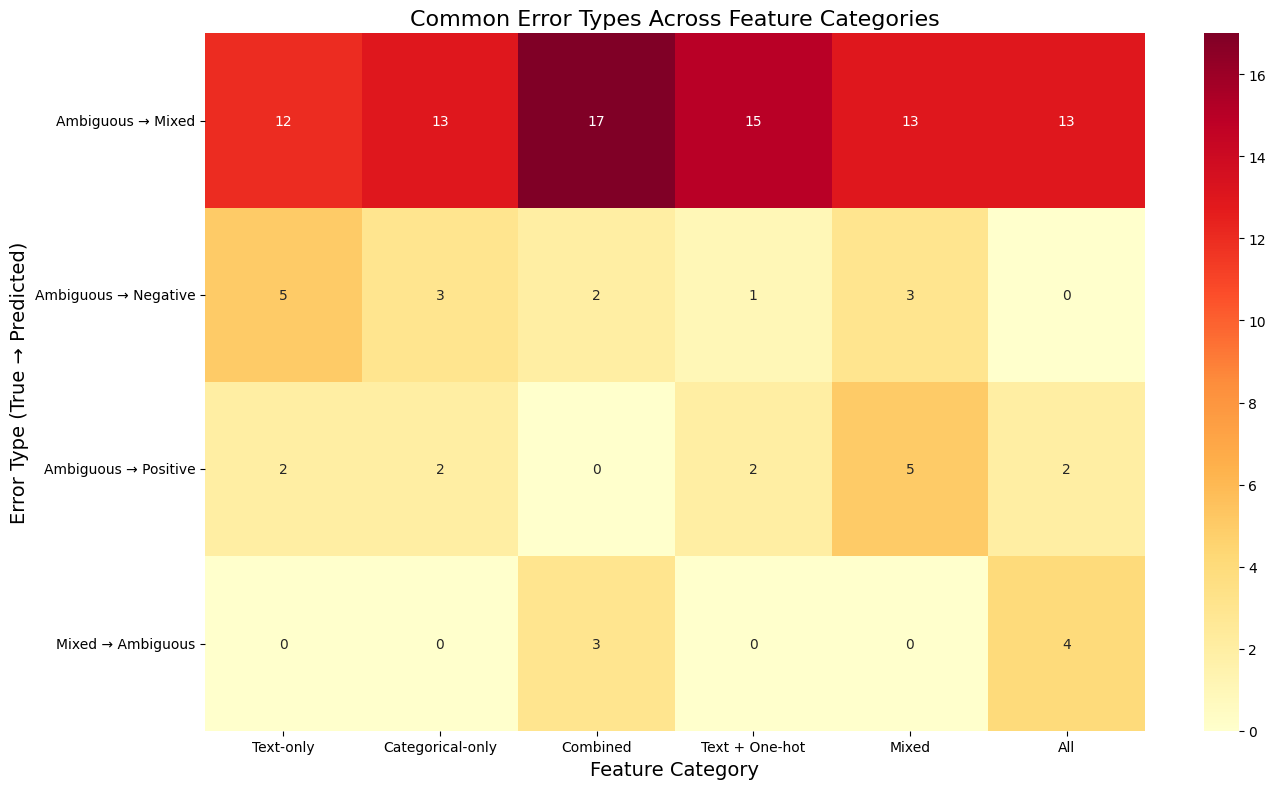

In [8]:
# Function to analyze errors for a specific model
def analyze_category_errors(category, results):
    """Analyze error patterns for a category's best model"""
    y_test = results['y_test']
    y_pred = results['y_pred']
    
    # Get misclassified examples
    misclassified_indices = np.where(y_pred != y_test)[0]
    
    if len(misclassified_indices) == 0:
        print(f"No errors found for {category}!")
        return None
    
    # Create error dataframe
    misclassified_data = []
    for idx in misclassified_indices:
        true_label = inv_label_mapping[y_test[idx]]
        pred_label = inv_label_mapping[y_pred[idx]]
        
        misclassified_data.append({
            'True Sentiment': true_label,
            'Predicted Sentiment': pred_label
        })
    
    misclassified_df = pd.DataFrame(misclassified_data)
    
    # Display summary
    error_rate = len(misclassified_indices) / len(y_test)
    print(f"\nError Analysis for {category} Best Model:")
    print(f"Total misclassified examples: {len(misclassified_indices)} out of {len(y_test)} ({error_rate:.1%})")
    
    # Analyze error patterns
    error_counts = misclassified_df.groupby(['True Sentiment', 'Predicted Sentiment']).size().reset_index()
    error_counts.columns = ['True Sentiment', 'Predicted Sentiment', 'Count']
    error_counts = error_counts.sort_values('Count', ascending=False)
    
    print("\nTop 5 misclassification patterns:")
    display(error_counts.head(5))
    
    # Plot confusion specifically for errors
    plt.figure(figsize=(10, 8))
    error_matrix = pd.crosstab(
        misclassified_df['True Sentiment'], 
        misclassified_df['Predicted Sentiment'], 
        normalize='index'
    )
    sns.heatmap(error_matrix, annot=True, cmap='Reds', fmt='.2f')
    plt.title(f'Error Distribution - {category} Best Model')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    return misclassified_df, error_counts

# Analyze errors for each category's best model
category_errors = {}
for category, results in category_results.items():
    error_results = analyze_category_errors(category, results)
    if error_results:
        category_errors[category] = error_results

# Compare error rates across categories
error_rates = []
for category, results in category_results.items():
    y_test = results['y_test']
    y_pred = results['y_pred']
    error_count = sum(y_pred != y_test)
    error_rates.append({
        'Category': category,
        'Error Rate': error_count / len(y_test),
        'Accuracy': 1 - (error_count / len(y_test)),
        'Error Count': error_count,
        'Total Examples': len(y_test)
    })

error_comparison = pd.DataFrame(error_rates).sort_values('Error Rate')

# Plot error rates
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Error Rate', data=error_comparison, palette='rocket_r')
plt.title('Error Rates by Feature Category', fontsize=16)
plt.ylabel('Error Rate', fontsize=14)
plt.xlabel('Feature Category', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for i, row in enumerate(error_comparison.iterrows()):
    info = row[1]
    plt.text(i, info['Error Rate'] + 0.01, f"{info['Error Count']} errors", 
             ha='center', va='bottom', fontsize=10)
    plt.text(i, info['Error Rate']/2, f"{info['Error Rate']:.1%}", 
             ha='center', va='center', color='white', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Compare common error types across categories
common_errors = {}
for category in category_errors:
    _, error_counts = category_errors[category]
    for i, row in error_counts.iterrows():
        if i < 3:  # Take top 3 errors
            error_type = f"{row['True Sentiment']} → {row['Predicted Sentiment']}"
            if error_type not in common_errors:
                common_errors[error_type] = {}
            common_errors[error_type][category] = row['Count']

# Create DataFrame for common errors
common_errors_df = pd.DataFrame.from_dict(common_errors, orient='index')
common_errors_df = common_errors_df.fillna(0)

# Plot common error types
plt.figure(figsize=(14, 8))
sns.heatmap(common_errors_df, annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('Common Error Types Across Feature Categories', fontsize=16)
plt.xlabel('Feature Category', fontsize=14)
plt.ylabel('Error Type (True → Predicted)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.1 Analysis

Categorical-only and All Features models tie for the best performance with identical accuracy rates. This is particularly interesting as it suggests that adding text features to an already strong categorical model doesn't necessarily improve overall performance.

Across all model types, the most frequent error is misclassifying Ambiguous sentiment as Mixed, as we saw already on section 4.1. This error occurs 9-17 times depending on the model, with Combined models showing the highest confusion rate (17 instances). This pattern makes sense as both categories represent unclear emotional states, but for different reasons - ambiguity stems from uncertainty while mixed sentiment comes from multiple conflicting emotions.

The Text-only model struggles most with distinguishing Mixed sentiment from other categories, frequently misclassifying it as Positive (17 errors) or mistaking Negative and Positive sentiment as Mixed (16 and 15 errors respectively). This suggests text-based features alone struggle to capture clear emotional boundaries.

Categorical-only models perform significantly better overall but still show confusion between Ambiguous and Mixed sentiments (9 errors). Interestingly, the All Features approach doesn't resolve this particular confusion (10 errors), suggesting this distinction remains challenging even with comprehensive feature representation.

The Mixed model shows a unique pattern of frequently misclassifying Positive sentiment as Mixed (16 errors), which might indicate it's overly sensitive to detecting mixed signals in predominantly positive content.

---

## 6. Conclusion

This study explored the challenging problem of sentiment analysis, focusing on how different feature representations can address key difficulties in this field.

Our experiments revealed that categorical features performed remarkably well compared to text-based approaches. This finding highlights that well-structured emotional metadata can effectively bypass many of the inherent complexities of natural language processing, such as contextual interpretation and linguistic variations. With this in mind, the similar performance between categorical-only and all-features approaches suggests there may be redundancy of adding text features into a already strong and rich emotional metada.

The most significant challenge encountered was accurately classifying ambiguous sentiment, which proved difficult across all feature combinations. This aligns with known challenges in sentiment analysis where uncertain emotional expressions create fundamental classification problems. Our models consistently struggled to distinguish between ambiguity and mixed sentiment, suggesting these closely related concepts require more sophisticated approaches than feature engineering alone can provide.

### 6.1 Future Work
Ideas:
- Two-stage classification for ambiguity detection: Creating a specialized approach where ambiguity is detected first before attempting more specific sentiment classification.
- Creating more ambiguous examples: Addressing data imbalance through targeted augmentation of the underrepresented ambiguous class. Even though we do not believe this was the main reason for the results, it could lead to better ones still.
- The dataset was limited in context, even though the assigment forced to use this dataset, using a dataset with conversation history, could lead to better understanding the context and making it possible to develop a way to move outside the single-text classification